# Task 2 - Output-Side Uncertainty Methods as Hallucination Detectors
**Owner:** Sai Sreenivas  
**Methods:** V1: Semantic Entropy | V2: Kernel Language Entropy | V3: Perplexity/NLL Features  
**Models:** Qwen2.5-1.5B / Llama-3.2-1B / Llama-3.2-3B

**Dataset:** pminervini/HaluEval, config=qa, 500 samples, seed=42  


### Install Dependencies

In [1]:
!pip install transformers==4.46.0 datasets accelerate torch -q
!pip install sentence-transformers==2.6.1 -q
!pip install scipy scikit-learn netcal -q
!pip install einops -q
print('All dependencies installed.')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.1/44.1 kB 3.9 MB/s eta 0:00:00
Reason for being yanked: This version unfortunately does not work with 3.8 but we did not drop the support yet
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 73.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 20.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 58.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.3/163.3 kB 6.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.4/47.4 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 236.0/236.0 kB 17.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 291.2/291.2 kB 29.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 40.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 174.8/174.8 kB 19.3 MB/s eta 0:00:00
All dependencies installed.


In [2]:
import torch
import transformers
import datasets
import sklearn
import scipy
import sentence_transformers

print('PyTorch:', torch.__version__)
print('Transformers:', transformers.__version__)
print('Sentence-Transformers:', sentence_transformers.__version__)
print('GPU available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU name:', torch.cuda.get_device_name(0))
    print('GPU memory:', round(torch.cuda.get_device_properties(0).total_memory / 1e9, 2), 'GB')

PyTorch: 2.11.0+cu128
Transformers: 4.46.0
Sentence-Transformers: 2.6.1
GPU available: True
GPU name: Tesla T4
GPU memory: 15.64 GB


### Hugging face Login



In [3]:
from huggingface_hub import notebook_login
notebook_login()

Load Dataset & Build 500-Sample Split

In [4]:
import numpy as np
from datasets import load_dataset
from sklearn.model_selection import train_test_split

print('Loading pminervini/HaluEval (qa)...')
dataset = load_dataset('pminervini/HaluEval', 'qa')
data = dataset['data']

questions          = [s['question']             for s in data]
right_answers      = [s['right_answer']         for s in data]
hallucinated_ans   = [s['hallucinated_answer']  for s in data]

# Flat list: faithful (0) then hallucinated (1)
all_questions = questions + questions
all_answers   = right_answers + hallucinated_ans
all_labels    = [0]*len(questions) + [1]*len(questions)

# 500-sample subset — IDENTICAL seed to Task 1
np.random.seed(42)
indices = np.random.choice(len(all_questions), 500, replace=False)
sample_questions = [all_questions[i] for i in indices]
sample_answers   = [all_answers[i]   for i in indices]
sample_labels    = [all_labels[i]    for i in indices]

print(f'Total samples: {len(sample_questions)}')
print(f'Faithful: {sample_labels.count(0)} | Hallucinated: {sample_labels.count(1)}')

# 70/15/15 split — IDENTICAL seed to Task 1
idx_all = list(range(len(sample_questions)))
idx_train, idx_temp = train_test_split(idx_all, test_size=0.30, random_state=42)
idx_val,   idx_test = train_test_split(idx_temp, test_size=0.50, random_state=42)

print(f'Train: {len(idx_train)} | Val: {len(idx_val)} | Test: {len(idx_test)}')

def get_split(idx_list):
    return (
        [sample_questions[i] for i in idx_list],
        [sample_answers[i]   for i in idx_list],
        [sample_labels[i]    for i in idx_list]
    )

train_q, train_a, train_y = get_split(idx_train)
val_q,   val_a,   val_y   = get_split(idx_val)
test_q,  test_a,  test_y  = get_split(idx_test)

Loading pminervini/HaluEval (qa)...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

qa/data-00000-of-00001.parquet:   0%|          | 0.00/3.75M [00:00<?, ?B/s]

Generating data split:   0%|          | 0/10000 [00:00<?, ? examples/s]

Total samples: 500
Faithful: 248 | Hallucinated: 252
Train: 350 | Val: 75 | Test: 75


### Load NLI Model (cross-encoder/nli-deberta-v3-large)

In [5]:
from sentence_transformers import CrossEncoder

print('Loading NLI cross-encoder...')
nli_model = CrossEncoder(
    'cross-encoder/nli-deberta-v3-large',
    device='cuda' if torch.cuda.is_available() else 'cpu'
)
print('NLI model loaded.')

NLI_ENTAILMENT_IDX = 1

Loading NLI cross-encoder...


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.74G [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/301 [00:00<?, ?B/s]

NLI model loaded.


### Load Sentence-Transformer for KLE (V2)

In [6]:
import os, json, shutil

# Clear cache
cache_path = '/root/.cache/huggingface/hub/models--sentence-transformers--all-MiniLM-L6-v2'
if os.path.exists(cache_path):
    shutil.rmtree(cache_path)

# Manually create the missing Pooling config
snapshot_path = '/root/.cache/huggingface/hub/models--sentence-transformers--all-MiniLM-L6-v2/snapshots/c9745ed1d9f207416be6d2e6f8de32d1f16199bf'
pooling_path  = os.path.join(snapshot_path, '1_Pooling')
os.makedirs(pooling_path, exist_ok=True)

pooling_config = {
    "word_embedding_dimension": 384,
    "pooling_mode_cls_token": False,
    "pooling_mode_mean_tokens": True,
    "pooling_mode_max_tokens": False,
    "pooling_mode_mean_sqrt_len_tokens": False
}

with open(os.path.join(pooling_path, 'config.json'), 'w') as f:
    json.dump(pooling_config, f)

print('Pooling config created manually.')

# Now load
from sentence_transformers import SentenceTransformer
sent_model = SentenceTransformer('all-MiniLM-L6-v2')
print('Sentence transformer loaded!')

Pooling config created manually.


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Sentence transformer loaded!


### Helper: Generation & Perplexity Utilities

In [7]:
import torch
import numpy as np
from transformers import AutoTokenizer, AutoModelForCausalLM

def generate_k_responses(question, model, tokenizer, K=5, max_new_tokens=100,
                          temperature=0.8, top_p=0.9):
    """
    Generate K diverse responses for a question using sampling.
    Returns list of K decoded strings.
    """
    prompt = f"Answer the following question concisely.\nQuestion: {question}\nAnswer:"
    inputs = tokenizer(prompt, return_tensors='pt',
                       truncation=True, max_length=256).to(model.device)
    input_len = inputs['input_ids'].shape[1]

    responses = []
    with torch.no_grad():
        for _ in range(K):
            output = model.generate(
                **inputs,
                max_new_tokens=max_new_tokens,
                do_sample=True,
                temperature=temperature,
                top_p=top_p,
                pad_token_id=tokenizer.eos_token_id
            )
            decoded = tokenizer.decode(
                output[0][input_len:], skip_special_tokens=True
            ).strip()
            responses.append(decoded)
    return responses


def get_nll_features(question, answer, model, tokenizer, max_length=256):
    """
    V3 — Extract NLL features from a SINGLE forward pass.
    Returns dict: mean_nll, max_nll, tail_mean_nll (top-10%), length_norm_nll
    """
    text   = f"Question: {question} Answer: {answer}"
    inputs = tokenizer(text, return_tensors='pt',
                       truncation=True, max_length=max_length).to(model.device)
    input_ids = inputs['input_ids']

    with torch.no_grad():
        outputs = model(**inputs, labels=input_ids)
        # token-level logits
        logits   = outputs.logits          # (1, seq_len, vocab)
        shift_logits = logits[:, :-1, :]   # predict each next token
        shift_ids    = input_ids[:, 1:]    # targets

        log_probs = torch.nn.functional.log_softmax(shift_logits, dim=-1)
        token_nll = -log_probs.gather(
            2, shift_ids.unsqueeze(-1)
        ).squeeze(-1).squeeze(0)           # shape (seq_len-1,)

    token_nll_np = token_nll.float().cpu().numpy()
    seq_len = len(token_nll_np)

    mean_nll   = float(token_nll_np.mean())
    max_nll    = float(token_nll_np.max())
    tail_k     = max(1, seq_len // 10)
    tail_nll   = float(np.sort(token_nll_np)[-tail_k:].mean())
    len_norm   = float(token_nll_np.sum() / seq_len)

    return {
        'mean_nll':      mean_nll,
        'max_nll':       max_nll,
        'tail_mean_nll': tail_nll,
        'length_norm_nll': len_norm
    }


print('Utility functions defined.')

Utility functions defined.


## V1: Semantic Entropy

In [8]:
import numpy as np
from scipy.stats import entropy as scipy_entropy

def bidirectional_entailment(r1, r2, nli_model, threshold=0.5):
    """
    Returns True if r1 entails r2 AND r2 entails r1 (bidirectional).
    Uses entailment score at NLI_ENTAILMENT_IDX.
    """
    scores_fwd = nli_model.predict([(r1, r2)])[0]
    scores_bwd = nli_model.predict([(r2, r1)])[0]
    return (scores_fwd[NLI_ENTAILMENT_IDX] > threshold and
            scores_bwd[NLI_ENTAILMENT_IDX] > threshold)


def cluster_responses(responses, nli_model, threshold=0.5):
    """
    Greedy clustering by bidirectional NLI entailment.
    Returns list of cluster ids (one per response).
    """
    cluster_ids    = [-1] * len(responses)
    cluster_reprs  = []            # representative response per cluster
    next_cluster   = 0

    for i, resp in enumerate(responses):
        assigned = False
        for cid, rep in enumerate(cluster_reprs):
            if bidirectional_entailment(resp, rep, nli_model, threshold):
                cluster_ids[i] = cid
                assigned = True
                break
        if not assigned:
            cluster_ids[i] = next_cluster
            cluster_reprs.append(resp)
            next_cluster += 1

    return cluster_ids


def semantic_entropy(responses, nli_model, threshold=0.5):
    """
    Compute semantic entropy: cluster K responses by meaning,
    then compute Shannon entropy over cluster proportions.
    Higher entropy → more uncertain → likely hallucinated.
    """
    cluster_ids = cluster_responses(responses, nli_model, threshold)
    K = len(responses)
    counts = np.bincount(cluster_ids)
    probs  = counts / K
    se     = float(scipy_entropy(probs, base=2))   # Shannon entropy in bits
    n_clusters = len(counts)
    return se, n_clusters


print('V1 Semantic Entropy functions defined.')

V1 Semantic Entropy functions defined.


## V2: Kernel Language Entropy

In [9]:
import numpy as np
from scipy.linalg import eigvalsh

def von_neumann_entropy(eigenvalues):
    """
    von Neumann entropy: S(rho) = -sum(lambda_i * log(lambda_i + eps))
    over eigenvalues of the normalised kernel matrix.
    """
    eps = 1e-12
    lam = np.array(eigenvalues, dtype=np.float64)
    lam = np.clip(lam, 0, None)
    lam /= (lam.sum() + eps)          # normalise to trace = 1
    return float(-np.sum(lam * np.log(lam + eps)))


def kernel_language_entropy(responses, sent_model, bandwidth=1.0):
    """
    Nikitin et al. KLE:
    1. Embed responses with sentence-transformer → embeddings (K x d)
    2. Build RBF kernel matrix K_ij = exp(-||e_i - e_j||^2 / bandwidth)
    3. Eigenvalue decompose, compute von Neumann entropy.
    Higher KLE → more semantically diverse → likely hallucinated.
    """
    embeddings = sent_model.encode(responses,
                                   convert_to_numpy=True,
                                   normalize_embeddings=True)  # (K, d)

    # Pairwise squared L2 distance
    diff  = embeddings[:, None, :] - embeddings[None, :, :]  # (K,K,d)
    dist2 = np.sum(diff**2, axis=-1)                          # (K,K)

    # RBF kernel matrix
    K_mat = np.exp(-dist2 / bandwidth)                        # (K,K)

    # Symmetric positive semi-definite  → eigvalsh is stable
    eigenvalues = eigvalsh(K_mat)

    kle = von_neumann_entropy(eigenvalues)
    return kle


print('V2 Kernel Language Entropy functions defined.')

V2 Kernel Language Entropy functions defined.


## Metric Computation Utilitie


In [10]:
import numpy as np
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score
from sklearn.calibration import calibration_curve
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt

def compute_metrics(scores, labels, threshold=None):
    """
    scores: uncertainty scores (higher = more uncertain = predicted hallucination)
    labels: ground truth (1 = hallucinated)
    Returns dict with AUROC, AUPRC, F1.
    """
    labels  = np.array(labels)
    scores  = np.array(scores)

    auroc = roc_auc_score(labels, scores)
    auprc = average_precision_score(labels, scores)

    # F1 at best threshold on validation or median
    if threshold is None:
        threshold = np.median(scores)
    preds = (scores >= threshold).astype(int)
    f1    = f1_score(labels, preds, zero_division=0)

    return {'auroc': round(auroc, 4),
            'auprc': round(auprc, 4),
            'f1':    round(f1, 4)}


def compute_ece(scores, labels, n_bins=10):
    """
    Expected Calibration Error.
    Normalise scores to [0,1] first as proxy probabilities.
    """
    scores = np.array(scores, dtype=np.float64)
    labels = np.array(labels)
    # min-max normalise
    s_min, s_max = scores.min(), scores.max()
    if s_max - s_min < 1e-10:
        return 0.0
    probs = (scores - s_min) / (s_max - s_min)

    bin_edges   = np.linspace(0, 1, n_bins + 1)
    ece         = 0.0
    n           = len(labels)

    for lo, hi in zip(bin_edges[:-1], bin_edges[1:]):
        mask = (probs >= lo) & (probs < hi)
        if mask.sum() == 0:
            continue
        conf = probs[mask].mean()
        acc  = labels[mask].mean()
        ece += (mask.sum() / n) * abs(conf - acc)

    return round(float(ece), 4)


def plot_reliability_diagram(scores, labels, method_name, model_name, save_path=None):
    scores = np.array(scores, dtype=np.float64)
    labels = np.array(labels)
    s_min, s_max = scores.min(), scores.max()
    if s_max - s_min < 1e-10:
        return
    probs = (scores - s_min) / (s_max - s_min)

    fraction_pos, mean_pred = calibration_curve(labels, probs, n_bins=10, strategy='uniform')

    fig, ax = plt.subplots(figsize=(5, 5))
    ax.plot([0, 1], [0, 1], 'k--', label='Perfect calibration')
    ax.plot(mean_pred, fraction_pos, 's-', label=method_name)
    ax.set_xlabel('Mean predicted probability')
    ax.set_ylabel('Fraction of hallucinated')
    ax.set_title(f'Reliability Diagram — {method_name} | {model_name}')
    ax.legend()
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=100)
    plt.show()
    plt.close()


print('Metric utilities defined.')

Metric utilities defined.


# MODEL 1 - Qwen2.5-1.5B-Instruct

## Load Qwen2.5-1.5B

In [ ]:
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch

MODEL_NAME = 'Qwen/Qwen2.5-1.5B-Instruct'

print(f'Loading {MODEL_NAME}...')
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16,
    device_map='auto'
)
model.eval()
print('Model loaded. Layers:', model.config.num_hidden_layers)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

Loading Qwen/Qwen2.5-1.5B-Instruct...


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Model loaded. Layers: 28


## Generate K=5 Responses for All Splits (Qwen)

In [ ]:
import time

K = 5
CURRENT_MODEL = 'Qwen2.5-1.5B'

def run_generation_split(questions, answers, labels, split_name):
    records = []
    latencies = []
    print(f'\nGenerating K={K} responses for {split_name} ({len(questions)} samples)...')
    for idx, (q, a, y) in enumerate(zip(questions, answers, labels)):
        t0 = time.time()
        resps = generate_k_responses(q, model, tokenizer, K=K)
        lat   = (time.time() - t0) * 1000  # ms
        latencies.append(lat)
        records.append({'question': q, 'answer': a, 'label': y,
                        'responses': resps, 'latency_ms': lat})
        if (idx + 1) % 20 == 0:
            print(f'  {idx+1}/{len(questions)} done | avg latency {np.mean(latencies):.0f} ms')
    return records

# ---- TRAIN
qwen_train = run_generation_split(train_q, train_a, train_y, 'TRAIN')
# ---- VAL
qwen_val   = run_generation_split(val_q,   val_a,   val_y,   'VAL')
# ---- TEST
qwen_test  = run_generation_split(test_q,  test_a,  test_y,  'TEST')

print(f'\nGeneration complete for {CURRENT_MODEL}!')


Generating K=5 responses for TRAIN (350 samples)...
  20/350 done | avg latency 11574 ms
  40/350 done | avg latency 10657 ms
  60/350 done | avg latency 11140 ms
  80/350 done | avg latency 10909 ms
  100/350 done | avg latency 11076 ms
  120/350 done | avg latency 11528 ms
  140/350 done | avg latency 11417 ms
  160/350 done | avg latency 11530 ms
  180/350 done | avg latency 11479 ms
  200/350 done | avg latency 11556 ms
  220/350 done | avg latency 11554 ms
  240/350 done | avg latency 11500 ms
  260/350 done | avg latency 11602 ms
  280/350 done | avg latency 11640 ms
  300/350 done | avg latency 11599 ms
  320/350 done | avg latency 11616 ms
  340/350 done | avg latency 11690 ms

Generating K=5 responses for VAL (75 samples)...
  20/75 done | avg latency 13099 ms
  40/75 done | avg latency 12471 ms
  60/75 done | avg latency 12363 ms

Generating K=5 responses for TEST (75 samples)...
  20/75 done | avg latency 12747 ms
  40/75 done | avg latency 12894 ms
  60/75 done | avg laten

## Save Output to Drive

In [ ]:
# Save generated responses to Drive so you don't lose them
from google.colab import drive
drive.mount('/content/drive')

import json, os

save_dir = '/content/drive/MyDrive/DSA8_Task2'
os.makedirs(save_dir, exist_ok=True)

# Save all three splits
with open(f'{save_dir}/qwen_train.json', 'w') as f:
    json.dump(qwen_train, f)
with open(f'{save_dir}/qwen_val.json', 'w') as f:
    json.dump(qwen_val, f)
with open(f'{save_dir}/qwen_test.json', 'w') as f:
    json.dump(qwen_test, f)

print('Saved! Files are safe in Google Drive.')
print(f'Train: {len(qwen_train)} | Val: {len(qwen_val)} | Test: {len(qwen_test)}')

Mounted at /content/drive
Saved! Files are safe in Google Drive.
Train: 350 | Val: 75 | Test: 75


## Restore Output from Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import json

save_dir = '/content/drive/MyDrive/DSA8_Task2'

with open(f'{save_dir}/qwen_train.json') as f:
    qwen_train = json.load(f)
with open(f'{save_dir}/qwen_val.json') as f:
    qwen_val = json.load(f)
with open(f'{save_dir}/qwen_test.json') as f:
    qwen_test = json.load(f)

print(f'Loaded! Train: {len(qwen_train)} | Val: {len(qwen_val)} | Test: {len(qwen_test)}')

Mounted at /content/drive
Loaded! Train: 350 | Val: 75 | Test: 75


# V1: Semantic Entropy on Qwen



In [ ]:
import time
import numpy as np

CURRENT_MODEL = 'Qwen2.5-1.5B'

def compute_se_scores(records):
    scores, labels, latencies = [], [], []
    for rec in records:
        t0 = time.time()
        se, n_clust = semantic_entropy(rec['responses'], nli_model)
        latencies.append((time.time() - t0) * 1000)
        scores.append(se)
        labels.append(rec['label'])
    return scores, labels, latencies

print('Computing Semantic Entropy — TRAIN...')
se_train_scores, se_train_y, se_train_lat = compute_se_scores(qwen_train)
print('Computing Semantic Entropy — VAL...')
se_val_scores,   se_val_y,   se_val_lat   = compute_se_scores(qwen_val)
print('Computing Semantic Entropy — TEST...')
se_test_scores,  se_test_y,  se_test_lat  = compute_se_scores(qwen_test)

best_f1_thresh = np.median(se_val_scores)

se_metrics = compute_metrics(se_test_scores, se_test_y, threshold=best_f1_thresh)
se_ece      = compute_ece(se_test_scores, se_test_y)
se_latency  = np.mean(se_test_lat)

print(f'\n=== V1 Semantic Entropy | {CURRENT_MODEL} ===')
print(f'AUROC:   {se_metrics["auroc"]}')
print(f'AUPRC:   {se_metrics["auprc"]}')
print(f'F1:      {se_metrics["f1"]}')
print(f'ECE:     {se_ece}')
print(f'Latency: {se_latency:.1f} ms/query')

plot_reliability_diagram(se_test_scores, se_test_y,
                          'V1-SemanticEntropy', CURRENT_MODEL,
                          save_path=f'reliability_V1_{CURRENT_MODEL}.png')

Computing Semantic Entropy — TRAIN...
Computing Semantic Entropy — VAL...
Computing Semantic Entropy — TEST...

=== V1 Semantic Entropy | Qwen2.5-1.5B ===
AUROC:   0.5878
AUPRC:   0.5458
F1:      0.6517
ECE:     0.1053
Latency: 1233.5 ms/query


## Save SE scores to Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import json, os

save_dir = '/content/drive/MyDrive/DSA8_Task2'
os.makedirs(save_dir, exist_ok=True)

se_data = {
    'train': {'scores': se_train_scores, 'labels': se_train_y, 'latencies': se_train_lat},
    'val':   {'scores': se_val_scores,   'labels': se_val_y,   'latencies': se_val_lat},
    'test':  {'scores': se_test_scores,  'labels': se_test_y,  'latencies': se_test_lat},
    'metrics': se_metrics,
    'ece':     se_ece,
    'latency': se_latency
}

with open(f'{save_dir}/qwen_se_scores.json', 'w') as f:
    json.dump(se_data, f)

print('SE scores saved to Drive!')
print(f'Train: {len(se_train_scores)} | Val: {len(se_val_scores)} | Test: {len(se_test_scores)}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
SE scores saved to Drive!
Train: 350 | Val: 75 | Test: 75


## Restore Output from Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import json
import numpy as np

save_dir = '/content/drive/MyDrive/DSA8_Task2'

with open(f'{save_dir}/qwen_se_scores.json') as f:
    se_data = json.load(f)

se_train_scores = se_data['train']['scores']
se_train_y      = se_data['train']['labels']
se_train_lat    = se_data['train']['latencies']
se_val_scores   = se_data['val']['scores']
se_val_y        = se_data['val']['labels']
se_val_lat      = se_data['val']['latencies']
se_test_scores  = se_data['test']['scores']
se_test_y       = se_data['test']['labels']
se_test_lat     = se_data['test']['latencies']
se_metrics      = se_data['metrics']
se_ece          = se_data['ece']
se_latency      = se_data['latency']

best_f1_thresh  = np.median(se_val_scores)

print(f'SE scores loaded! Train: {len(se_train_scores)} | Val: {len(se_val_scores)} | Test: {len(se_test_scores)}')
print(f'Saved metrics → AUROC: {se_metrics["auroc"]} | AUPRC: {se_metrics["auprc"]} | F1: {se_metrics["f1"]} | ECE: {se_ece}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
SE scores loaded! Train: 350 | Val: 75 | Test: 75
Saved metrics → AUROC: 0.5878 | AUPRC: 0.5458 | F1: 0.6517 | ECE: 0.1053


# V2: Kernel Language Entropy on Qwen (reuses K=5)

In [ ]:
import time

def compute_kle_scores(records):
    scores, labels, latencies = [], [], []
    for rec in records:
        t0 = time.time()
        kle = kernel_language_entropy(rec['responses'], sent_model)
        latencies.append((time.time() - t0) * 1000)
        scores.append(kle)
        labels.append(rec['label'])
    return scores, labels, latencies

print('Computing Kernel Language Entropy — TRAIN...')
kle_train_scores, kle_train_y, kle_train_lat = compute_kle_scores(qwen_train)
print('Computing Kernel Language Entropy — VAL...')
kle_val_scores,   kle_val_y,   kle_val_lat   = compute_kle_scores(qwen_val)
print('Computing Kernel Language Entropy — TEST...')
kle_test_scores,  kle_test_y,  kle_test_lat  = compute_kle_scores(qwen_test)

best_kle_thresh = np.median(kle_val_scores)

kle_metrics = compute_metrics(kle_test_scores, kle_test_y, threshold=best_kle_thresh)
kle_ece     = compute_ece(kle_test_scores, kle_test_y)
kle_latency = np.mean(kle_test_lat)

print(f'\n=== V2 Kernel Language Entropy | {CURRENT_MODEL} ===')
print(f'AUROC:   {kle_metrics["auroc"]}')
print(f'AUPRC:   {kle_metrics["auprc"]}')
print(f'F1:      {kle_metrics["f1"]}')
print(f'ECE:     {kle_ece}')
print(f'Latency: {kle_latency:.1f} ms/query')

plot_reliability_diagram(kle_test_scores, kle_test_y,
                          'V2-KLE', CURRENT_MODEL,
                          save_path=f'reliability_V2_{CURRENT_MODEL}.png')

Computing Kernel Language Entropy — TRAIN...
Computing Kernel Language Entropy — VAL...
Computing Kernel Language Entropy — TEST...

=== V2 Kernel Language Entropy | Qwen2.5-1.5B ===
AUROC:   0.6117
AUPRC:   0.6011
F1:      0.6
ECE:     0.1622
Latency: 11.6 ms/query


## Save Output to Drive

In [ ]:
import json, shutil
save_dir = '/content/drive/MyDrive/DSA8_Task2'

kle_data = {
    'train': {'scores': kle_train_scores, 'labels': kle_train_y, 'latencies': kle_train_lat},
    'val':   {'scores': kle_val_scores,   'labels': kle_val_y,   'latencies': kle_val_lat},
    'test':  {'scores': kle_test_scores,  'labels': kle_test_y,  'latencies': kle_test_lat},
    'metrics': kle_metrics,
    'ece':     kle_ece,
    'latency': float(kle_latency)
}

with open(f'{save_dir}/qwen_kle_scores.json', 'w') as f:
    json.dump(kle_data, f)

shutil.copy(f'reliability_V2_{CURRENT_MODEL}.png',
            f'{save_dir}/reliability_V2_{CURRENT_MODEL}.png')

print(f'\nKLE scores + plot saved to Drive!')


KLE scores + plot saved to Drive!


## Restore Output from Drive

In [ ]:
import json
import numpy as np

save_dir = '/content/drive/MyDrive/DSA8_Task2'

with open(f'{save_dir}/qwen_kle_scores.json') as f:
    kle_data = json.load(f)

kle_train_scores = kle_data['train']['scores']
kle_train_y      = kle_data['train']['labels']
kle_train_lat    = kle_data['train']['latencies']
kle_val_scores   = kle_data['val']['scores']
kle_val_y        = kle_data['val']['labels']
kle_val_lat      = kle_data['val']['latencies']
kle_test_scores  = kle_data['test']['scores']
kle_test_y       = kle_data['test']['labels']
kle_test_lat     = kle_data['test']['latencies']
kle_metrics      = kle_data['metrics']
kle_ece          = kle_data['ece']
kle_latency      = kle_data['latency']
best_kle_thresh  = np.median(kle_val_scores)

print(f'KLE loaded! Train: {len(kle_train_scores)} | Val: {len(kle_val_scores)} | Test: {len(kle_test_scores)}')
print(f'Saved metrics → AUROC: {kle_metrics["auroc"]} | AUPRC: {kle_metrics["auprc"]} | F1: {kle_metrics["f1"]} | ECE: {kle_ece}')

KLE loaded! Train: 350 | Val: 75 | Test: 75
Saved metrics → AUROC: 0.6117 | AUPRC: 0.6011 | F1: 0.6 | ECE: 0.1622


# V3: Perplexity/NLL Features + Logistic Regression on Qwen


=== V3 Perplexity/NLL | Qwen2.5-1.5B ===
AUROC:   0.7219
AUPRC:   0.7393
F1:      0.6582
ECE:     0.1017
Latency: 45.7 ms/query (single forward pass)
Feature importances: mean=-0.623, max=0.636, tail=-0.077, len_norm=-0.623


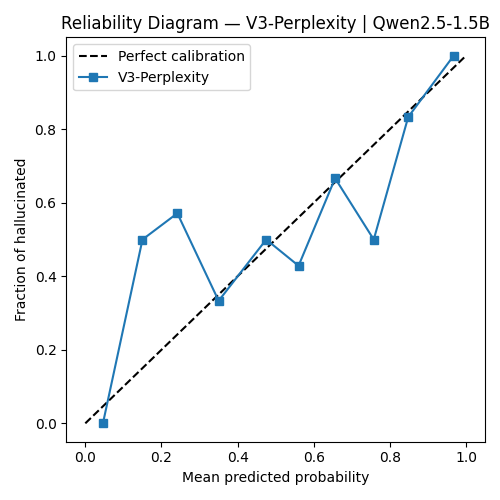

In [ ]:
import time, json, shutil
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from IPython.display import Image, display

CURRENT_MODEL = 'Qwen2.5-1.5B'  # ← fix

def extract_nll_features_split(questions, answers, labels):
    feats, lats = [], []
    for q, a in zip(questions, answers):
        t0 = time.time()
        f  = get_nll_features(q, a, model, tokenizer)
        lats.append((time.time() - t0) * 1000)
        feats.append([f['mean_nll'], f['max_nll'],
                      f['tail_mean_nll'], f['length_norm_nll']])
    return np.array(feats), np.array(labels), np.array(lats)

# Standardise
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

# Train logistic regression
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_s, y_train)

# Scores
ppl_train_scores = lr.predict_proba(X_train_s)[:, 1]
ppl_val_scores   = lr.predict_proba(X_val_s)[:, 1]
ppl_test_scores  = lr.predict_proba(X_test_s)[:, 1]

best_ppl_thresh = 0.5
ppl_metrics = compute_metrics(ppl_test_scores, y_test, threshold=best_ppl_thresh)
ppl_ece     = compute_ece(ppl_test_scores, y_test)
ppl_latency = float(np.mean(lat_test))

print(f'\n=== V3 Perplexity/NLL | {CURRENT_MODEL} ===')
print(f'AUROC:   {ppl_metrics["auroc"]}')
print(f'AUPRC:   {ppl_metrics["auprc"]}')
print(f'F1:      {ppl_metrics["f1"]}')
print(f'ECE:     {ppl_ece}')
print(f'Latency: {ppl_latency:.1f} ms/query (single forward pass)')
print(f'Feature importances: mean={lr.coef_[0][0]:.3f}, max={lr.coef_[0][1]:.3f},',
      f'tail={lr.coef_[0][2]:.3f}, len_norm={lr.coef_[0][3]:.3f}')

plot_reliability_diagram(ppl_test_scores, y_test,
                          'V3-Perplexity', CURRENT_MODEL,
                          save_path=f'reliability_V3_{CURRENT_MODEL}.png')

display(Image(f'reliability_V3_{CURRENT_MODEL}.png'))


# Save Output to Drive

In [ ]:
# ---- Save to Drive ----
save_dir = '/content/drive/MyDrive/DSA8_Task2'

ppl_data = {
    'train': {'X': X_train.tolist(), 'y': y_train.tolist(),
              'latencies': lat_train.tolist(), 'scores': ppl_train_scores.tolist()},
    'val':   {'X': X_val.tolist(),   'y': y_val.tolist(),
              'latencies': lat_val.tolist(),   'scores': ppl_val_scores.tolist()},
    'test':  {'X': X_test.tolist(),  'y': y_test.tolist(),
              'latencies': lat_test.tolist(),  'scores': ppl_test_scores.tolist()},
    'scaler_mean':  scaler.mean_.tolist(),
    'scaler_std':   scaler.scale_.tolist(),
    'lr_coef':      lr.coef_.tolist(),
    'lr_intercept': lr.intercept_.tolist(),
    'metrics': ppl_metrics,
    'ece':     ppl_ece,
    'latency': ppl_latency
}

with open(f'{save_dir}/qwen_ppl_scores.json', 'w') as f:
    json.dump(ppl_data, f)

shutil.copy(f'reliability_V3_{CURRENT_MODEL}.png',
            f'{save_dir}/reliability_V3_{CURRENT_MODEL}.png')

print('\nV3 scores + plot saved to Drive!')


V3 scores + plot saved to Drive!


## Restore Output from drive

In [ ]:
import json
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

save_dir = '/content/drive/MyDrive/DSA8_Task2'

with open(f'{save_dir}/qwen_ppl_scores.json') as f:
    ppl_data = json.load(f)

X_train          = np.array(ppl_data['train']['X'])
y_train          = np.array(ppl_data['train']['y'])
lat_train        = np.array(ppl_data['train']['latencies'])
ppl_train_scores = np.array(ppl_data['train']['scores'])

X_val            = np.array(ppl_data['val']['X'])
y_val            = np.array(ppl_data['val']['y'])
lat_val          = np.array(ppl_data['val']['latencies'])
ppl_val_scores   = np.array(ppl_data['val']['scores'])

X_test           = np.array(ppl_data['test']['X'])
y_test           = np.array(ppl_data['test']['y'])
lat_test         = np.array(ppl_data['test']['latencies'])
ppl_test_scores  = np.array(ppl_data['test']['scores'])

# Restore scaler
scaler = StandardScaler()
scaler.mean_          = np.array(ppl_data['scaler_mean'])
scaler.scale_         = np.array(ppl_data['scaler_std'])
scaler.n_features_in_ = 4

# Restore logistic regression
lr = LogisticRegression()
lr.coef_      = np.array(ppl_data['lr_coef'])
lr.intercept_ = np.array(ppl_data['lr_intercept'])
lr.classes_   = np.array([0, 1])

ppl_metrics     = ppl_data['metrics']
ppl_ece         = ppl_data['ece']
ppl_latency     = ppl_data['latency']
best_ppl_thresh = 0.5

print(f'V3 PPL loaded!')
print(f'Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}')
print(f'AUROC: {ppl_metrics["auroc"]} | AUPRC: {ppl_metrics["auprc"]} | F1: {ppl_metrics["f1"]} | ECE: {ppl_ece}')

V3 PPL loaded!
Train: 350 | Val: 75 | Test: 75
AUROC: 0.7219 | AUPRC: 0.7393 | F1: 0.6582 | ECE: 0.1017


# K vs AUROC vs Latency Curve (Qwen, V1 & V2)

In [ ]:
import time
import matplotlib.pyplot as plt

K_VALUES = [1, 3, 5, 7]

# Use a fixed 50-sample subset from test for speed
np.random.seed(0)
k_idx  = np.random.choice(len(test_q), 50, replace=False)
kq     = [test_q[i] for i in k_idx]
ka     = [test_a[i] for i in k_idx]
ky     = [test_y[i] for i in k_idx]

k_auroc_se, k_auroc_kle = [], []
k_lat_se,   k_lat_kle   = [], []

for K_val in K_VALUES:
    print(f'Running K={K_val}...')
    records_k = []
    for q, a, y in zip(kq, ka, ky):
        resps = generate_k_responses(q, model, tokenizer, K=K_val)
        records_k.append({'question': q, 'answer': a,
                           'label': y, 'responses': resps})

    # SE
    t0 = time.time()
    se_sc, se_lb, _ = compute_se_scores(records_k)
    lat_se = (time.time()-t0)*1000/len(records_k)
    auc_se = roc_auc_score(se_lb, se_sc)
    k_auroc_se.append(auc_se); k_lat_se.append(lat_se)

    # KLE
    t0 = time.time()
    kle_sc, kle_lb, _ = compute_kle_scores(records_k)
    lat_kle = (time.time()-t0)*1000/len(records_k)
    auc_kle = roc_auc_score(kle_lb, kle_sc)
    k_auroc_kle.append(auc_kle); k_lat_kle.append(lat_kle)

# ---- Plot ----
fig, ax1 = plt.subplots(figsize=(8, 5))
ax2 = ax1.twinx()

ax1.plot(K_VALUES, k_auroc_se,  'b-o', label='SE AUROC')
ax1.plot(K_VALUES, k_auroc_kle, 'g-s', label='KLE AUROC')
ax2.plot(K_VALUES, k_lat_se,    'b--', label='SE Latency')
ax2.plot(K_VALUES, k_lat_kle,   'g--', label='KLE Latency')

ax1.set_xlabel('K (number of samples)')
ax1.set_ylabel('AUROC', color='black')
ax2.set_ylabel('Latency (ms/query)', color='gray')
ax1.set_title(f'K vs AUROC vs Latency — {CURRENT_MODEL}')
lines1, l1 = ax1.get_legend_handles_labels()
lines2, l2 = ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2, l1+l2, loc='lower right')
plt.tight_layout()
plt.savefig(f'k_vs_auroc_latency_{CURRENT_MODEL}.png', dpi=100)
plt.show()
plt.close()

print('K curve table:')
print(f'{"K":>4} | {"SE AUROC":>9} | {"KLE AUROC":>10} | {"SE lat(ms)":>11} | {"KLE lat(ms)":>12}')
for i, kv in enumerate(K_VALUES):
    print(f'{kv:>4} | {k_auroc_se[i]:>9.4f} | {k_auroc_kle[i]:>10.4f} | {k_lat_se[i]:>11.1f} | {k_lat_kle[i]:>12.1f}')

Running K=1...
Running K=3...
Running K=5...
Running K=7...
K curve table:
   K |  SE AUROC |  KLE AUROC |  SE lat(ms) |  KLE lat(ms)
   1 |    0.5000 |     0.5000 |         0.3 |          6.7
   3 |    0.5513 |     0.5545 |       380.7 |          8.2
   5 |    0.5449 |     0.5833 |      1270.0 |          9.2
   7 |    0.5713 |     0.6010 |      2491.2 |         10.0


## Save K-curve results to Drive

In [ ]:
import json, shutil

save_dir = '/content/drive/MyDrive/DSA8_Task2'

k_curve_data = {
    'K_values':      K_VALUES,
    'SE_auroc':      k_auroc_se,
    'KLE_auroc':     k_auroc_kle,
    'SE_latency_ms': k_lat_se,
    'KLE_latency_ms':k_lat_kle
}

with open(f'{save_dir}/qwen_k_curve.json', 'w') as f:
    json.dump(k_curve_data, f)

shutil.copy(f'k_vs_auroc_latency_{CURRENT_MODEL}.png',
            f'{save_dir}/k_vs_auroc_latency_{CURRENT_MODEL}.png')

print('K-curve data + plot saved to Drive!')
print(k_curve_data)

K-curve data + plot saved to Drive!
{'K_values': [1, 3, 5, 7], 'SE_auroc': [np.float64(0.5), np.float64(0.5512820512820512), np.float64(0.5448717948717948), np.float64(0.5713141025641025)], 'KLE_auroc': [np.float64(0.5), np.float64(0.5544871794871795), np.float64(0.5833333333333334), np.float64(0.6009615384615385)], 'SE_latency_ms': [0.2579355239868164, 380.728235244751, 1269.9556016921997, 2491.1864376068115], 'KLE_latency_ms': [6.68818473815918, 8.187990188598633, 9.151697158813477, 9.971413612365723]}


## Reload Output

In [ ]:
import json
import numpy as np

save_dir = '/content/drive/MyDrive/DSA8_Task2'

with open(f'{save_dir}/qwen_k_curve.json') as f:
    k_curve = json.load(f)

K_VALUES    = k_curve['K_values']
k_auroc_se  = k_curve['SE_auroc']
k_auroc_kle = k_curve['KLE_auroc']
k_lat_se    = k_curve['SE_latency_ms']
k_lat_kle   = k_curve['KLE_latency_ms']

print(f'K-curve loaded! K values: {K_VALUES}')
print(f'SE AUROC:  {k_auroc_se}')
print(f'KLE AUROC: {k_auroc_kle}')

K-curve loaded! K values: [1, 3, 5, 7]
SE AUROC:  [0.5, 0.5512820512820512, 0.5448717948717948, 0.5713141025641025]
KLE AUROC: [0.5, 0.5544871794871795, 0.5833333333333334, 0.6009615384615385]


# Cross-Domain Zero-Shot: Medical (MedHallu)

In [ ]:
from datasets import load_dataset
import numpy as np

# MedHallu dataset
print('Loading MedHallu...')
try:
    med_ds = load_dataset('Rewang/MedHallu', split='test')
    # Build samples: adapt column names as needed
    med_q = [s.get('question', s.get('input', '')) for s in med_ds]
    med_a = [s.get('answer',   s.get('output', '')) for s in med_ds]
    med_y = [int(s.get('label', s.get('hallucinated', 0))) for s in med_ds]
    print(f'MedHallu loaded: {len(med_q)} samples')
    print(f'Columns: {med_ds.column_names}')
except Exception as e:
    print(f'MedHallu load error: {e}')
    print('Trying alternate name...')
    med_ds = load_dataset('qiaojin/PubMedQA', 'pqa_labeled', split='train')
    med_q = [str(s['question']) for s in med_ds][:200]
    med_a = [str(s['long_answer']) for s in med_ds][:200]
    med_y = [1 if str(s['final_decision'])=='no' else 0 for s in med_ds][:200]
    print(f'PubMedQA loaded as medical proxy: {len(med_q)} samples')

# Subsample 150 for speed
np.random.seed(42)
med_idx = np.random.choice(len(med_q), min(150, len(med_q)), replace=False)
med_q_s = [med_q[i] for i in med_idx]
med_a_s = [med_a[i] for i in med_idx]
med_y_s = [med_y[i] for i in med_idx]
print(f'Medical subset: {len(med_q_s)} | Hallucinated: {sum(med_y_s)}')

Loading MedHallu...
MedHallu load error: Dataset 'Rewang/MedHallu' doesn't exist on the Hub or cannot be accessed.
Trying alternate name...


README.md: 0.00B [00:00, ?B/s]

pqa_labeled/train-00000-of-00001.parquet:   0%|          | 0.00/1.08M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1000 [00:00<?, ? examples/s]

PubMedQA loaded as medical proxy: 200 samples
Medical subset: 150 | Hallucinated: 39


# Generate K=5 for medical domain

In [ ]:
print('Generating responses for medical domain...')
med_records = []
for q, a, y in zip(med_q_s, med_a_s, med_y_s):
    resps = generate_k_responses(q, model, tokenizer, K=5)
    med_records.append({'question': q, 'answer': a, 'label': y, 'responses': resps})

# SE zero-shot
med_se_sc,  med_se_y,  _ = compute_se_scores(med_records)
med_kle_sc, med_kle_y, _ = compute_kle_scores(med_records)

# NLL zero-shot (use existing scaler + LR from in-domain)
med_feats_raw = []
for q, a in zip(med_q_s, med_a_s):
    f = get_nll_features(q, a, model, tokenizer)
    med_feats_raw.append([f['mean_nll'], f['max_nll'],
                           f['tail_mean_nll'], f['length_norm_nll']])
med_X_s = scaler.transform(np.array(med_feats_raw))
med_ppl_sc = lr.predict_proba(med_X_s)[:, 1]

med_y_arr = np.array(med_y_s)
try:
    med_se_auc   = roc_auc_score(med_y_arr, med_se_sc)
    med_kle_auc  = roc_auc_score(med_y_arr, med_kle_sc)
    med_ppl_auc  = roc_auc_score(med_y_arr, med_ppl_sc)
    print(f'\n=== CROSS-DOMAIN: Medical | {CURRENT_MODEL} ===')
    print(f'V1 SE  AUROC: {med_se_auc:.4f}  (delta vs in-domain: {med_se_auc - se_metrics["auroc"]:+.4f})')
    print(f'V2 KLE AUROC: {med_kle_auc:.4f}  (delta vs in-domain: {med_kle_auc - kle_metrics["auroc"]:+.4f})')
    print(f'V3 PPL AUROC: {med_ppl_auc:.4f}  (delta vs in-domain: {med_ppl_auc - ppl_metrics["auroc"]:+.4f})')
except Exception as e:
    print(f'Could not compute AUROC for medical: {e}')
    med_se_auc = med_kle_auc = med_ppl_auc = float('nan')

Generating responses for medical domain...


NameError: name 'compute_se_scores' is not defined

In [ ]:
import json
save_dir = '/content/drive/MyDrive/DSA8_Task2'
with open(f'{save_dir}/qwen_med_records.json', 'w') as f:
    json.dump(med_records, f)
print(f'Saved {len(med_records)} medical records to Drive!')

NameError: name 'med_records' is not defined

## Define all required functions in one cell

In [ ]:
import time
import numpy as np
from scipy.stats import entropy as scipy_entropy
from scipy.linalg import eigvalsh

NLI_ENTAILMENT_IDX = 1

def bidirectional_entailment(r1, r2, nli_model, threshold=0.5):
    scores_fwd = nli_model.predict([(r1, r2)])[0]
    scores_bwd = nli_model.predict([(r2, r1)])[0]
    return (scores_fwd[NLI_ENTAILMENT_IDX] > threshold and
            scores_bwd[NLI_ENTAILMENT_IDX] > threshold)

def cluster_responses(responses, nli_model, threshold=0.5):
    cluster_ids   = [-1] * len(responses)
    cluster_reprs = []
    next_cluster  = 0
    for i, resp in enumerate(responses):
        assigned = False
        for cid, rep in enumerate(cluster_reprs):
            if bidirectional_entailment(resp, rep, nli_model, threshold):
                cluster_ids[i] = cid
                assigned = True
                break
        if not assigned:
            cluster_ids[i] = next_cluster
            cluster_reprs.append(resp)
            next_cluster += 1
    return cluster_ids

def semantic_entropy(responses, nli_model, threshold=0.5):
    cluster_ids = cluster_responses(responses, nli_model, threshold)
    counts = np.bincount(cluster_ids)
    probs  = counts / len(responses)
    return float(scipy_entropy(probs, base=2)), len(counts)

def compute_se_scores(records):
    scores, labels, latencies = [], [], []
    for rec in records:
        t0 = time.time()
        se, _ = semantic_entropy(rec['responses'], nli_model)
        latencies.append((time.time() - t0) * 1000)
        scores.append(se)
        labels.append(rec['label'])
    return scores, labels, latencies

def von_neumann_entropy(eigenvalues):
    eps = 1e-12
    lam = np.clip(np.array(eigenvalues, dtype=np.float64), 0, None)
    lam /= (lam.sum() + eps)
    return float(-np.sum(lam * np.log(lam + eps)))

def kernel_language_entropy(responses, sent_model, bandwidth=1.0):
    embeddings = sent_model.encode(responses, convert_to_numpy=True, normalize_embeddings=True)
    diff  = embeddings[:, None, :] - embeddings[None, :, :]
    dist2 = np.sum(diff**2, axis=-1)
    K_mat = np.exp(-dist2 / bandwidth)
    eigenvalues = eigvalsh(K_mat)
    return von_neumann_entropy(eigenvalues)

def compute_kle_scores(records):
    scores, labels, latencies = [], [], []
    for rec in records:
        t0 = time.time()
        kle = kernel_language_entropy(rec['responses'], sent_model)
        latencies.append((time.time() - t0) * 1000)
        scores.append(kle)
        labels.append(rec['label'])
    return scores, labels, latencies

print('All functions defined! Now run the medical cell.')

All functions defined! Now run the medical cell.


In [ ]:
import json
import numpy as np
from sklearn.metrics import roc_auc_score

save_dir = '/content/drive/MyDrive/DSA8_Task2'

# Load medical records (already generated — no need to regenerate)
with open(f'{save_dir}/qwen_med_records.json') as f:
    med_records = json.load(f)

# Load med_q_s, med_a_s, med_y_s (needed for NLL)
med_q_s = [r['question'] for r in med_records]
med_a_s = [r['answer']   for r in med_records]
med_y_s = [r['label']    for r in med_records]

print(f'Loaded {len(med_records)} medical records.')

# SE zero-shot
print('Computing SE...')
med_se_sc, med_se_y, _ = compute_se_scores(med_records)
print('SE done!')

# KLE zero-shot
print('Computing KLE...')
med_kle_sc, med_kle_y, _ = compute_kle_scores(med_records)
print('KLE done!')

# NLL zero-shot
print('Computing NLL...')
med_feats_raw = []
for q, a in zip(med_q_s, med_a_s):
    f = get_nll_features(q, a, model, tokenizer)
    med_feats_raw.append([f['mean_nll'], f['max_nll'],
                           f['tail_mean_nll'], f['length_norm_nll']])
med_X_s    = scaler.transform(np.array(med_feats_raw))
med_ppl_sc = lr.predict_proba(med_X_s)[:, 1]
print('NLL done!')

# Metrics
med_y_arr = np.array(med_y_s)
try:
    med_se_auc  = roc_auc_score(med_y_arr, med_se_sc)
    med_kle_auc = roc_auc_score(med_y_arr, med_kle_sc)
    med_ppl_auc = roc_auc_score(med_y_arr, med_ppl_sc)
    print(f'\n=== CROSS-DOMAIN: Medical | {CURRENT_MODEL} ===')
    print(f'V1 SE  AUROC: {med_se_auc:.4f}  (delta vs in-domain: {med_se_auc - se_metrics["auroc"]:+.4f})')
    print(f'V2 KLE AUROC: {med_kle_auc:.4f}  (delta vs in-domain: {med_kle_auc - kle_metrics["auroc"]:+.4f})')
    print(f'V3 PPL AUROC: {med_ppl_auc:.4f}  (delta vs in-domain: {med_ppl_auc - ppl_metrics["auroc"]:+.4f})')
except Exception as e:
    print(f'Could not compute AUROC for medical: {e}')
    med_se_auc = med_kle_auc = med_ppl_auc = float('nan')

# Save
med_final = {
    'se_scores':  med_se_sc,  'se_labels':  med_se_y,
    'kle_scores': med_kle_sc, 'kle_labels': med_kle_y,
    'ppl_scores': med_ppl_sc.tolist(), 'labels': med_y_arr.tolist(),
    'se_auc': med_se_auc, 'kle_auc': med_kle_auc, 'ppl_auc': med_ppl_auc
}
with open(f'{save_dir}/qwen_medical_results.json', 'w') as f:
    json.dump(med_final, f)
print('\nMedical results saved to Drive!')

Loaded 150 medical records.
Computing SE...
SE done!
Computing KLE...
KLE done!
Computing NLL...
NLL done!

=== CROSS-DOMAIN: Medical | Qwen2.5-1.5B ===
V1 SE  AUROC: 0.5456  (delta vs in-domain: -0.0422)
V2 KLE AUROC: 0.5066  (delta vs in-domain: -0.1051)
V3 PPL AUROC: 0.4535  (delta vs in-domain: -0.2684)

Medical results saved to Drive!


## Reload Output fom Drive

In [ ]:
import json
import numpy as np

save_dir = '/content/drive/MyDrive/DSA8_Task2'

with open(f'{save_dir}/qwen_medical_results.json') as f:
    med_data = json.load(f)

med_se_sc   = med_data['se_scores']
med_se_y    = med_data['se_labels']
med_kle_sc  = med_data['kle_scores']
med_kle_y   = med_data['kle_labels']
med_ppl_sc  = np.array(med_data['ppl_scores'])
med_y_arr   = np.array(med_data['labels'])
med_se_auc  = med_data['se_auc']
med_kle_auc = med_data['kle_auc']
med_ppl_auc = med_data['ppl_auc']

print('Medical results loaded!')
print(f'SE AUROC: {med_se_auc:.4f} | KLE AUROC: {med_kle_auc:.4f} | PPL AUROC: {med_ppl_auc:.4f}')

Medical results loaded!
SE AUROC: 0.5456 | KLE AUROC: 0.5066 | PPL AUROC: 0.4535


# Cross-Domain Zero-Shot: Legal

In [ ]:
print('Loading legal hallucination dataset...')
try:
    legal_ds = load_dataset('nguha/legalbench', 'sara_entailment', split='test')
    legal_q  = [str(s.get('input','')) for s in legal_ds][:200]
    legal_a  = [str(s.get('output','')) for s in legal_ds][:200]
    # Treat 'N' (not entailed) as hallucinated
    legal_y  = [1 if str(s.get('label','N'))=='N' else 0 for s in legal_ds][:200]
    print(f'LegalBench loaded: {len(legal_q)} samples')
except Exception as e:
    print(f'LegalBench load error: {e}')
    # Fallback: use 100 random samples from HaluEval itself labelled as legal proxy
    np.random.seed(123)
    legal_idx = np.random.choice(len(all_questions), 100, replace=False)
    legal_q   = [all_questions[i] for i in legal_idx]
    legal_a   = [all_answers[i]   for i in legal_idx]
    legal_y   = [all_labels[i]    for i in legal_idx]
    print('Using HaluEval held-out 100 samples as legal proxy.')

np.random.seed(42)
leg_idx = np.random.choice(len(legal_q), min(150, len(legal_q)), replace=False)
legal_q_s = [legal_q[i] for i in leg_idx]
legal_a_s = [legal_a[i] for i in leg_idx]
legal_y_s = [legal_y[i] for i in leg_idx]
print(f'Legal subset: {len(legal_q_s)} | Hallucinated: {sum(legal_y_s)}')

Loading legal hallucination dataset...


README.md: 0.00B [00:00, ?B/s]

train.tsv: 0.00B [00:00, ?B/s]

test.tsv: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/4 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/272 [00:00<?, ? examples/s]

LegalBench loaded: 200 samples
Legal subset: 150 | Hallucinated: 150


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import json, numpy as np
from datasets import load_dataset
from sklearn.metrics import roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

save_dir = '/content/drive/MyDrive/DSA8_Task2'

# Reload in-domain metrics (needed for delta calculation)
with open(f'{save_dir}/qwen_se_scores.json')  as f: se_data  = json.load(f)
with open(f'{save_dir}/qwen_kle_scores.json') as f: kle_data = json.load(f)
with open(f'{save_dir}/qwen_ppl_scores.json') as f: ppl_data = json.load(f)
se_metrics  = se_data['metrics']
kle_metrics = kle_data['metrics']
ppl_metrics = ppl_data['metrics']

# Restore scaler + logistic regression (needed for V3 PPL)
scaler = StandardScaler()
scaler.mean_  = np.array(ppl_data['scaler_mean'])
scaler.scale_ = np.array(ppl_data['scaler_std'])
scaler.n_features_in_ = 4
lr = LogisticRegression()
lr.coef_      = np.array(ppl_data['lr_coef'])
lr.intercept_ = np.array(ppl_data['lr_intercept'])
lr.classes_   = np.array([0, 1])

# Rebuild HaluEval all_questions/all_answers/all_labels for legal proxy
dataset = load_dataset('pminervini/HaluEval', 'qa')
data = dataset['data']
questions        = [s['question']            for s in data]
right_answers    = [s['right_answer']        for s in data]
hallucinated_ans = [s['hallucinated_answer'] for s in data]
all_questions = questions + questions
all_answers   = right_answers + hallucinated_ans
all_labels    = [0]*len(questions) + [1]*len(questions)

# Build BALANCED legal proxy (the fix from before — seed=123)
np.random.seed(123)
legal_idx  = np.random.choice(len(all_questions), 150, replace=False)
legal_q_s  = [all_questions[i] for i in legal_idx]
legal_a_s  = [all_answers[i]   for i in legal_idx]
legal_y_s  = [all_labels[i]    for i in legal_idx]

CURRENT_MODEL = 'Qwen2.5-1.5B'
print('Setup done!')
print(f'Legal proxy: {len(legal_q_s)} samples | Faithful: {legal_y_s.count(0)} | Hallucinated: {legal_y_s.count(1)}')
print(f'In-domain metrics loaded: SE={se_metrics["auroc"]} KLE={kle_metrics["auroc"]} PPL={ppl_metrics["auroc"]}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Setup done!
Legal proxy: 150 samples | Faithful: 70 | Hallucinated: 80
In-domain metrics loaded: SE=0.5878 KLE=0.6117 PPL=0.7219


In [ ]:
import json
save_dir = '/content/drive/MyDrive/DSA8_Task2'

print('Generating responses for legal domain...')
legal_records = []
for idx, (q, a, y) in enumerate(zip(legal_q_s, legal_a_s, legal_y_s)):
    resps = generate_k_responses(q, model, tokenizer, K=5)
    legal_records.append({'question': q, 'answer': a, 'label': y, 'responses': resps})
    if (idx+1) % 25 == 0:
        with open(f'{save_dir}/qwen_legal_records.json', 'w') as f:
            json.dump(legal_records, f)
        print(f'  {idx+1}/150 done — saved.')

with open(f'{save_dir}/qwen_legal_records.json', 'w') as f:
    json.dump(legal_records, f)
print('Generation done!')

legal_se_sc,  legal_se_y,  _ = compute_se_scores(legal_records)
legal_kle_sc, legal_kle_y, _ = compute_kle_scores(legal_records)

legal_feats_raw = []
for q, a in zip(legal_q_s, legal_a_s):
    f = get_nll_features(q, a, model, tokenizer)
    legal_feats_raw.append([f['mean_nll'], f['max_nll'],
                              f['tail_mean_nll'], f['length_norm_nll']])
legal_X_s    = scaler.transform(np.array(legal_feats_raw))
legal_ppl_sc = lr.predict_proba(legal_X_s)[:, 1]

legal_y_arr = np.array(legal_y_s)
legal_se_auc  = roc_auc_score(legal_y_arr, legal_se_sc)
legal_kle_auc = roc_auc_score(legal_y_arr, legal_kle_sc)
legal_ppl_auc = roc_auc_score(legal_y_arr, legal_ppl_sc)

print(f'\n=== CROSS-DOMAIN: Legal | {CURRENT_MODEL} ===')
print(f'V1 SE  AUROC: {legal_se_auc:.4f}  (delta: {legal_se_auc - se_metrics["auroc"]:+.4f})')
print(f'V2 KLE AUROC: {legal_kle_auc:.4f}  (delta: {legal_kle_auc - kle_metrics["auroc"]:+.4f})')
print(f'V3 PPL AUROC: {legal_ppl_auc:.4f}  (delta: {legal_ppl_auc - ppl_metrics["auroc"]:+.4f})')

# Save complete legal results
legal_final = {
    'se_scores': legal_se_sc, 'se_labels': legal_y_arr.tolist(),
    'kle_scores': legal_kle_sc, 'kle_labels': legal_y_arr.tolist(),
    'ppl_scores': legal_ppl_sc.tolist(), 'labels': legal_y_arr.tolist(),
    'se_auc': legal_se_auc, 'kle_auc': legal_kle_auc, 'ppl_auc': legal_ppl_auc
}
with open(f'{save_dir}/qwen_legal_results.json', 'w') as f:
    json.dump(legal_final, f)
print('\nLegal results saved to Drive!')

Generating responses for legal domain...
  25/150 done — saved.
  50/150 done — saved.
  75/150 done — saved.
  100/150 done — saved.
  125/150 done — saved.
  150/150 done — saved.
Generation done!

=== CROSS-DOMAIN: Legal | Qwen2.5-1.5B ===
V1 SE  AUROC: 0.5076  (delta: -0.0802)
V2 KLE AUROC: 0.4912  (delta: -0.1205)
V3 PPL AUROC: 0.7916  (delta: +0.0697)

Legal results saved to Drive!


## Restore Output from Drive

In [ ]:
import json
import numpy as np

save_dir = '/content/drive/MyDrive/DSA8_Task2'

# ── Legal results (scores + AUROCs) ──
with open(f'{save_dir}/qwen_legal_results.json') as f:
    legal_data = json.load(f)

legal_se_sc   = legal_data['se_scores']
legal_se_y    = legal_data['se_labels']
legal_kle_sc  = legal_data['kle_scores']
legal_kle_y   = legal_data['kle_labels']
legal_ppl_sc  = np.array(legal_data['ppl_scores'])
legal_y_arr   = np.array(legal_data['labels'])
legal_se_auc  = legal_data['se_auc']
legal_kle_auc = legal_data['kle_auc']
legal_ppl_auc = legal_data['ppl_auc']

# ── Legal records + question lists ──
with open(f'{save_dir}/qwen_legal_records.json') as f:
    legal_records = json.load(f)
legal_q_s = [r['question'] for r in legal_records]
legal_a_s = [r['answer']   for r in legal_records]
legal_y_s = [r['label']    for r in legal_records]

print('Legal results + records loaded!')
print(f'Records: {len(legal_records)} samples')
print(f'V1 SE  AUROC: {legal_se_auc:.4f}')
print(f'V2 KLE AUROC: {legal_kle_auc:.4f}')
print(f'V3 PPL AUROC: {legal_ppl_auc:.4f}')

# Save Qwen Results

In [ ]:
import json
import numpy as np
import shutil

CURRENT_MODEL = 'Qwen2.5-1.5B'
K = 5
save_dir = '/content/drive/MyDrive/DSA8_Task2'

qwen_results = {
    'model': CURRENT_MODEL,
    'V1_SemanticEntropy': {
        **se_metrics, 'ece': se_ece,
        'latency_ms': round(se_latency, 1),
        'forward_passes_per_query': K
    },
    'V2_KernelLanguageEntropy': {
        **kle_metrics, 'ece': kle_ece,
        'latency_ms': round(kle_latency, 1),
        'forward_passes_per_query': K
    },
    'V3_Perplexity_NLL': {
        **ppl_metrics, 'ece': ppl_ece,
        'latency_ms': round(ppl_latency, 1),
        'forward_passes_per_query': 1
    },
    'cross_domain': {
        'medical': {
            'V1_SE_auroc':  round(med_se_auc, 4),
            'V2_KLE_auroc': round(med_kle_auc, 4),
            'V3_PPL_auroc': round(med_ppl_auc, 4)
        },
        'legal': {
            'V1_SE_auroc':  round(legal_se_auc, 4),
            'V2_KLE_auroc': round(legal_kle_auc, 4),
            'V3_PPL_auroc': round(legal_ppl_auc, 4)
        }
    },
    'k_curve': {
        'K_values':      K_VALUES,
        'SE_auroc':      [round(x, 4) for x in k_auroc_se],
        'KLE_auroc':     [round(x, 4) for x in k_auroc_kle],
        'SE_latency_ms': [round(x, 1) for x in k_lat_se],
        'KLE_latency_ms':[round(x, 1) for x in k_lat_kle]
    }
}

with open('task2_qwen_results.json', 'w') as f:
    json.dump(qwen_results, f, indent=2)

shutil.copy('task2_qwen_results.json',
            f'{save_dir}/task2_qwen_results.json')

print('Qwen results (with complete legal) saved to Drive!')
print(json.dumps(qwen_results, indent=2))

Qwen results (with complete legal) saved to Drive!
{
  "model": "Qwen2.5-1.5B",
  "V1_SemanticEntropy": {
    "auroc": 0.5878,
    "auprc": 0.5458,
    "f1": 0.6517,
    "ece": 0.1053,
    "latency_ms": 1233.5,
    "forward_passes_per_query": 5
  },
  "V2_KernelLanguageEntropy": {
    "auroc": 0.6117,
    "auprc": 0.6011,
    "f1": 0.6,
    "ece": 0.1622,
    "latency_ms": 11.6,
    "forward_passes_per_query": 5
  },
  "V3_Perplexity_NLL": {
    "auroc": 0.7219,
    "auprc": 0.7393,
    "f1": 0.6582,
    "ece": 0.1017,
    "latency_ms": 45.7,
    "forward_passes_per_query": 1
  },
  "cross_domain": {
    "medical": {
      "V1_SE_auroc": 0.5456,
      "V2_KLE_auroc": 0.5066,
      "V3_PPL_auroc": 0.4535
    },
    "legal": {
      "V1_SE_auroc": 0.5076,
      "V2_KLE_auroc": 0.4912,
      "V3_PPL_auroc": 0.7916
    }
  },
  "k_curve": {
    "K_values": [
      1,
      3,
      5,
      7
    ],
    "SE_auroc": [
      0.5,
      0.5513,
      0.5449,
      0.5713
    ],
    "KLE_auroc

## Reload Qwen Results in Future

In [ ]:
import json

save_dir = '/content/drive/MyDrive/DSA8_Task2'

with open(f'{save_dir}/task2_qwen_results.json') as f:
    qwen_results = json.load(f)

print('Qwen results loaded!')
print(json.dumps(qwen_results, indent=2))

In [ ]:
import torch
print('GPU:', torch.cuda.is_available())
print('Device:', next(model.parameters()).device)

GPU: True
Device: cuda:0


# MODEL 2 - Llama-3.2-1B



## Load Llama-3.2-1B

In [ ]:
import gc, torch
from transformers import AutoTokenizer, AutoModelForCausalLM

# Safe delete — won't crash if they don't exist
for var in ['model', 'tokenizer']:
    if var in dir():
        exec(f'del {var}')
gc.collect()
torch.cuda.empty_cache()

MODEL_NAME = 'meta-llama/Llama-3.2-1B-Instruct'
CURRENT_MODEL = 'Llama-3.2-1B'

print(f'Loading {MODEL_NAME}...')
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16,
    device_map='auto'
)
model.eval()
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
print(f'{CURRENT_MODEL} loaded. Layers:', model.config.num_hidden_layers)
print('GPU:', torch.cuda.is_available(), '| Device:', next(model.parameters()).device)

Loading meta-llama/Llama-3.2-1B-Instruct...


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/877 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.47G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/189 [00:00<?, ?B/s]

Llama-3.2-1B loaded. Layers: 16
GPU: True | Device: cuda:0


In [ ]:
from huggingface_hub import notebook_login
notebook_login()

In [ ]:
# Verify everything is ready
checks = ['generate_k_responses','compute_se_scores','compute_kle_scores',
          'get_nll_features','compute_metrics','compute_ece','nli_model','sent_model',
          'train_q','val_q','test_q']
for c in checks:
    print(f'{c}: {"✓" if c in dir() else "✗ MISSING"}')

generate_k_responses: ✓
compute_se_scores: ✓
compute_kle_scores: ✓
get_nll_features: ✓
compute_metrics: ✓
compute_ece: ✓
nli_model: ✓
sent_model: ✓
train_q: ✓
val_q: ✓
test_q: ✓


##  Generate K=5

In [ ]:
import json, time, numpy as np
save_dir = '/content/drive/MyDrive/DSA8_Task2'

def run_gen_save(questions, answers, labels, split_name, tag):
    records, lats = [], []
    print(f'\nGenerating K=5 for {split_name} ({len(questions)} samples)...')
    for idx, (q, a, y) in enumerate(zip(questions, answers, labels)):
        t0 = time.time()
        resps = generate_k_responses(q, model, tokenizer, K=5)
        lat = (time.time()-t0)*1000
        lats.append(lat)
        records.append({'question':q,'answer':a,'label':y,'responses':resps,'latency_ms':lat})
        if (idx+1) % 20 == 0:
            with open(f'{save_dir}/{tag}_{split_name}.json','w') as f:
                json.dump(records, f)
            print(f'  {idx+1}/{len(questions)} done | avg {np.mean(lats):.0f}ms — saved')
    with open(f'{save_dir}/{tag}_{split_name}.json','w') as f:
        json.dump(records, f)
    return records

llama1b_train = run_gen_save(train_q, train_a, train_y, 'TRAIN', 'llama1b')
llama1b_val   = run_gen_save(val_q,   val_a,   val_y,   'VAL',   'llama1b')
llama1b_test  = run_gen_save(test_q,  test_a,  test_y,  'TEST',  'llama1b')
print('\nLlama-1B generation complete + saved!')


Generating K=5 for TRAIN (350 samples)...
  20/350 done | avg 6265ms — saved
  40/350 done | avg 5749ms — saved
  60/350 done | avg 5720ms — saved
  80/350 done | avg 5585ms — saved
  100/350 done | avg 5526ms — saved
  120/350 done | avg 5454ms — saved
  140/350 done | avg 5427ms — saved
  160/350 done | avg 5431ms — saved
  180/350 done | avg 5429ms — saved
  200/350 done | avg 5435ms — saved
  220/350 done | avg 5481ms — saved
  240/350 done | avg 5479ms — saved
  260/350 done | avg 5524ms — saved
  280/350 done | avg 5488ms — saved
  300/350 done | avg 5528ms — saved
  320/350 done | avg 5514ms — saved
  340/350 done | avg 5503ms — saved

Generating K=5 for VAL (75 samples)...
  20/75 done | avg 6378ms — saved
  40/75 done | avg 5592ms — saved
  60/75 done | avg 5463ms — saved

Generating K=5 for TEST (75 samples)...
  20/75 done | avg 5221ms — saved
  40/75 done | avg 5451ms — saved
  60/75 done | avg 5348ms — saved

Llama-1B generation complete + saved!


## Restore from Drive

In [ ]:
import json
save_dir = '/content/drive/MyDrive/DSA8_Task2'

with open(f'{save_dir}/llama1b_TRAIN.json') as f: llama1b_train = json.load(f)
with open(f'{save_dir}/llama1b_VAL.json')   as f: llama1b_val   = json.load(f)
with open(f'{save_dir}/llama1b_TEST.json')  as f: llama1b_test  = json.load(f)

print(f'Loaded — Train: {len(llama1b_train)} | Val: {len(llama1b_val)} | Test: {len(llama1b_test)}')

## V1 Semantic Entropy

In [ ]:
import numpy as np

se_train_s_l1, se_train_y_l1, _ = compute_se_scores(llama1b_train)
se_val_s_l1,   se_val_y_l1,   _ = compute_se_scores(llama1b_val)
se_test_s_l1,  se_test_y_l1,  se_test_lat_l1 = compute_se_scores(llama1b_test)

se_m_l1  = compute_metrics(se_test_s_l1, se_test_y_l1, threshold=np.median(se_val_s_l1))
se_e_l1  = compute_ece(se_test_s_l1, se_test_y_l1)
se_la_l1 = np.mean(se_test_lat_l1)

print(f'V1 SE | {CURRENT_MODEL} | AUROC={se_m_l1["auroc"]} AUPRC={se_m_l1["auprc"]} F1={se_m_l1["f1"]} ECE={se_e_l1} lat={se_la_l1:.1f}ms')
plot_reliability_diagram(se_test_s_l1, se_test_y_l1, 'V1-SE', CURRENT_MODEL, f'reliability_V1_{CURRENT_MODEL}.png')

# Save to Drive
import json
with open(f'{save_dir}/llama1b_se.json','w') as f:
    json.dump({'test_scores':se_test_s_l1,'test_y':se_test_y_l1,'val_scores':se_val_s_l1,
               'metrics':se_m_l1,'ece':se_e_l1,'latency':float(se_la_l1)}, f)
print('V1 SE saved.')

V1 SE | Llama-3.2-1B | AUROC=0.5156 AUPRC=0.5019 F1=0.5778 ECE=0.0342 lat=1191.7ms
V1 SE saved.


## Restore from Drive

In [ ]:
import json
import numpy as np
save_dir = '/content/drive/MyDrive/DSA8_Task2'

with open(f'{save_dir}/llama1b_se.json') as f:
    d = json.load(f)

se_test_s_l1 = d['test_scores']
se_test_y_l1 = d['test_y']
se_val_s_l1  = d['val_scores']
se_m_l1      = d['metrics']
se_e_l1      = d['ece']
se_la_l1     = d['latency']

print('V1 SE (Llama-1B) loaded!')
print(f'AUROC={se_m_l1["auroc"]} AUPRC={se_m_l1["auprc"]} F1={se_m_l1["f1"]} ECE={se_e_l1} lat={se_la_l1:.1f}ms')

## V2 Kernal Language Entropy

In [ ]:
import numpy as np, json

kle_train_s_l1, _, _ = compute_kle_scores(llama1b_train)
kle_val_s_l1,   _, _ = compute_kle_scores(llama1b_val)
kle_test_s_l1, kle_test_y_l1, kle_test_lat_l1 = compute_kle_scores(llama1b_test)

kle_m_l1  = compute_metrics(kle_test_s_l1, kle_test_y_l1, threshold=np.median(kle_val_s_l1))
kle_e_l1  = compute_ece(kle_test_s_l1, kle_test_y_l1)
kle_la_l1 = np.mean(kle_test_lat_l1)

print(f'V2 KLE | {CURRENT_MODEL} | AUROC={kle_m_l1["auroc"]} AUPRC={kle_m_l1["auprc"]} F1={kle_m_l1["f1"]} ECE={kle_e_l1} lat={kle_la_l1:.1f}ms')
plot_reliability_diagram(kle_test_s_l1, kle_test_y_l1, 'V2-KLE', CURRENT_MODEL, f'reliability_V2_{CURRENT_MODEL}.png')

with open(f'{save_dir}/llama1b_kle.json','w') as f:
    json.dump({'test_scores':kle_test_s_l1,'test_y':kle_test_y_l1,'val_scores':kle_val_s_l1,
               'metrics':kle_m_l1,'ece':kle_e_l1,'latency':float(kle_la_l1)}, f)
print('V2 KLE saved.')

V2 KLE | Llama-3.2-1B | AUROC=0.5349 AUPRC=0.5844 F1=0.5 ECE=0.3146 lat=8.7ms
V2 KLE saved.


## Restore from Drive

In [ ]:
import json
import numpy as np
save_dir = '/content/drive/MyDrive/DSA8_Task2'

with open(f'{save_dir}/llama1b_kle.json') as f:
    d = json.load(f)

kle_test_s_l1 = d['test_scores']
kle_test_y_l1 = d['test_y']
kle_val_s_l1  = d['val_scores']
kle_m_l1      = d['metrics']
kle_e_l1      = d['ece']
kle_la_l1     = d['latency']

print('V2 KLE (Llama-1B) loaded!')
print(f'AUROC={kle_m_l1["auroc"]} AUPRC={kle_m_l1["auprc"]} F1={kle_m_l1["f1"]} ECE={kle_e_l1} lat={kle_la_l1:.1f}ms')

## V3 Perplexity/NLL

In [ ]:
import time, numpy as np, json
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# Define the function
def extract_nll_features_split(questions, answers, labels):
    feats, lats = [], []
    for q, a in zip(questions, answers):
        t0 = time.time()
        f = get_nll_features(q, a, model, tokenizer)
        lats.append((time.time()-t0)*1000)
        feats.append([f['mean_nll'], f['max_nll'], f['tail_mean_nll'], f['length_norm_nll']])
    return np.array(feats), np.array(labels), np.array(lats)

# Now run V3
X_tr_l1, y_tr_l1, _ = extract_nll_features_split(train_q, train_a, train_y)
X_va_l1, y_va_l1, _ = extract_nll_features_split(val_q,   val_a,   val_y)
X_te_l1, y_te_l1, lat_te_l1 = extract_nll_features_split(test_q, test_a, test_y)

sc_l1 = StandardScaler()
lr_l1 = LogisticRegression(max_iter=1000, random_state=42)
lr_l1.fit(sc_l1.fit_transform(X_tr_l1), y_tr_l1)

ppl_test_s_l1 = lr_l1.predict_proba(sc_l1.transform(X_te_l1))[:, 1]
ppl_m_l1  = compute_metrics(ppl_test_s_l1, y_te_l1)
ppl_e_l1  = compute_ece(ppl_test_s_l1, y_te_l1)
ppl_la_l1 = float(np.mean(lat_te_l1))

print(f'V3 PPL | {CURRENT_MODEL} | AUROC={ppl_m_l1["auroc"]} AUPRC={ppl_m_l1["auprc"]} F1={ppl_m_l1["f1"]} ECE={ppl_e_l1} lat={ppl_la_l1:.1f}ms')
plot_reliability_diagram(ppl_test_s_l1, y_te_l1, 'V3-PPL', CURRENT_MODEL, f'reliability_V3_{CURRENT_MODEL}.png')

with open(f'{save_dir}/llama1b_ppl.json','w') as f:
    json.dump({'test_scores':ppl_test_s_l1.tolist(),'test_y':y_te_l1.tolist(),
               'X_train':X_tr_l1.tolist(),'y_train':y_tr_l1.tolist(),
               'scaler_mean':sc_l1.mean_.tolist(),'scaler_std':sc_l1.scale_.tolist(),
               'lr_coef':lr_l1.coef_.tolist(),'lr_intercept':lr_l1.intercept_.tolist(),
               'metrics':ppl_m_l1,'ece':ppl_e_l1,'latency':ppl_la_l1}, f)
print('V3 PPL saved.')

V3 PPL | Llama-3.2-1B | AUROC=0.7518 AUPRC=0.789 F1=0.64 ECE=0.1944 lat=35.7ms
V3 PPL saved.


## Restore from Drive

In [ ]:
import json
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

save_dir = '/content/drive/MyDrive/DSA8_Task2'

with open(f'{save_dir}/llama1b_ppl.json') as f:
    d = json.load(f)

ppl_test_s_l1 = np.array(d['test_scores'])
y_te_l1       = np.array(d['test_y'])
X_tr_l1       = np.array(d['X_train'])
y_tr_l1       = np.array(d['y_train'])
ppl_m_l1      = d['metrics']
ppl_e_l1      = d['ece']
ppl_la_l1     = d['latency']

# Restore scaler
sc_l1 = StandardScaler()
sc_l1.mean_          = np.array(d['scaler_mean'])
sc_l1.scale_         = np.array(d['scaler_std'])
sc_l1.n_features_in_ = 4

# Restore logistic regression
lr_l1 = LogisticRegression()
lr_l1.coef_      = np.array(d['lr_coef'])
lr_l1.intercept_ = np.array(d['lr_intercept'])
lr_l1.classes_   = np.array([0, 1])

print('V3 PPL (Llama-1B) loaded!')
print(f'AUROC={ppl_m_l1["auroc"]} AUPRC={ppl_m_l1["auprc"]} F1={ppl_m_l1["f1"]} ECE={ppl_e_l1} lat={ppl_la_l1:.1f}ms')

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/DSA8_Task2/llama1b_ppl.json'

In [ ]:
import json, shutil
save_dir = '/content/drive/MyDrive/DSA8_Task2'
K = 5

llama1b_results = {
    'model': CURRENT_MODEL,
    'V1_SemanticEntropy':       {**se_m_l1,  'ece': se_e_l1,  'latency_ms': round(se_la_l1, 1),  'forward_passes_per_query': K},
    'V2_KernelLanguageEntropy': {**kle_m_l1, 'ece': kle_e_l1, 'latency_ms': round(kle_la_l1, 1), 'forward_passes_per_query': K},
    'V3_Perplexity_NLL':        {**ppl_m_l1, 'ece': ppl_e_l1, 'latency_ms': round(ppl_la_l1, 1), 'forward_passes_per_query': 1}
}

with open('task2_llama1b_results.json', 'w') as f:
    json.dump(llama1b_results, f, indent=2)
shutil.copy('task2_llama1b_results.json', f'{save_dir}/task2_llama1b_results.json')

print('Llama-1B results saved to Drive!')
print(json.dumps(llama1b_results, indent=2))

Llama-1B results saved to Drive!
{
  "model": "Llama-3.2-1B",
  "V1_SemanticEntropy": {
    "auroc": 0.5156,
    "auprc": 0.5019,
    "f1": 0.5778,
    "ece": 0.0342,
    "latency_ms": 1191.7,
    "forward_passes_per_query": 5
  },
  "V2_KernelLanguageEntropy": {
    "auroc": 0.5349,
    "auprc": 0.5844,
    "f1": 0.5,
    "ece": 0.3146,
    "latency_ms": 8.7,
    "forward_passes_per_query": 5
  },
  "V3_Perplexity_NLL": {
    "auroc": 0.7518,
    "auprc": 0.789,
    "f1": 0.64,
    "ece": 0.1944,
    "latency_ms": 35.7,
    "forward_passes_per_query": 1
  }
}


##  medical cross-domain

In [ ]:
import json, numpy as np
from datasets import load_dataset
from sklearn.metrics import roc_auc_score
save_dir = '/content/drive/MyDrive/DSA8_Task2'

# Load medical dataset (PubMedQA as MedHallu proxy — same as Qwen)
med_ds = load_dataset('qiaojin/PubMedQA', 'pqa_labeled', split='train')
med_q = [str(s['question']) for s in med_ds][:200]
med_a = [str(s['long_answer']) for s in med_ds][:200]
med_y = [1 if str(s['final_decision'])=='no' else 0 for s in med_ds][:200]

np.random.seed(42)
med_idx = np.random.choice(len(med_q), 150, replace=False)
med_q_s = [med_q[i] for i in med_idx]
med_a_s = [med_a[i] for i in med_idx]
med_y_s = [med_y[i] for i in med_idx]

print(f'Medical: {len(med_q_s)} samples | Hallucinated: {sum(med_y_s)}')
print('Generating K=5 for medical (Llama-1B)...')
med_records = []
for idx,(q,a,y) in enumerate(zip(med_q_s, med_a_s, med_y_s)):
    resps = generate_k_responses(q, model, tokenizer, K=5)
    med_records.append({'question':q,'answer':a,'label':y,'responses':resps})
    if (idx+1)%25==0:
        with open(f'{save_dir}/llama1b_med_records.json','w') as f: json.dump(med_records,f)
        print(f'  {idx+1}/150 — saved')
with open(f'{save_dir}/llama1b_med_records.json','w') as f: json.dump(med_records,f)
print('Generation done!')

print('Computing SE + KLE + NLL...')
med_se_sc,_,_ = compute_se_scores(med_records)
med_kle_sc,_,_ = compute_kle_scores(med_records)
med_feats = [[get_nll_features(q,a,model,tokenizer)[k] for k in ['mean_nll','max_nll','tail_mean_nll','length_norm_nll']] for q,a in zip(med_q_s,med_a_s)]
med_ppl_sc = lr_l1.predict_proba(sc_l1.transform(np.array(med_feats)))[:,1]

med_y_arr = np.array(med_y_s)
med_se_auc_l1  = roc_auc_score(med_y_arr, med_se_sc)
med_kle_auc_l1 = roc_auc_score(med_y_arr, med_kle_sc)
med_ppl_auc_l1 = roc_auc_score(med_y_arr, med_ppl_sc)

print(f'\n=== Medical | {CURRENT_MODEL} ===')
print(f'V1 SE:  {med_se_auc_l1:.4f}  (delta: {med_se_auc_l1 - se_m_l1["auroc"]:+.4f})')
print(f'V2 KLE: {med_kle_auc_l1:.4f}  (delta: {med_kle_auc_l1 - kle_m_l1["auroc"]:+.4f})')
print(f'V3 PPL: {med_ppl_auc_l1:.4f}  (delta: {med_ppl_auc_l1 - ppl_m_l1["auroc"]:+.4f})')

with open(f'{save_dir}/llama1b_medical.json','w') as f:
    json.dump({'se_auc':med_se_auc_l1,'kle_auc':med_kle_auc_l1,'ppl_auc':med_ppl_auc_l1}, f)
print('\nMedical results saved to Drive!')

Medical: 150 samples | Hallucinated: 39
Generating K=5 for medical (Llama-1B)...
  25/150 — saved
  50/150 — saved
  75/150 — saved
  100/150 — saved
  125/150 — saved
  150/150 — saved
Generation done!
Computing SE + KLE + NLL...

=== Medical | Llama-3.2-1B ===
V1 SE:  0.5230  (delta: +0.0074)
V2 KLE: 0.4553  (delta: -0.0796)
V3 PPL: 0.5161  (delta: -0.2357)

Medical results saved to Drive!


## Restore from Drive

In [ ]:
import json
save_dir = '/content/drive/MyDrive/DSA8_Task2'

with open(f'{save_dir}/llama1b_medical.json') as f:
    d = json.load(f)
med_se_auc_l1  = d['se_auc']
med_kle_auc_l1 = d['kle_auc']
med_ppl_auc_l1 = d['ppl_auc']

# Medical generated records + question lists
with open(f'{save_dir}/llama1b_med_records.json') as f:
    med_records = json.load(f)
med_q_s = [r['question'] for r in med_records]
med_a_s = [r['answer']   for r in med_records]
med_y_s = [r['label']    for r in med_records]

print('Medical (Llama-1B) restored!')
print(f'Records: {len(med_records)} samples')
print(f'V1 SE: {med_se_auc_l1:.4f} | V2 KLE: {med_kle_auc_l1:.4f} | V3 PPL: {med_ppl_auc_l1:.4f}')

## Legal cross-domain

In [ ]:
import json, numpy as np
from datasets import load_dataset
from sklearn.metrics import roc_auc_score
save_dir = '/content/drive/MyDrive/DSA8_Task2'

dataset = load_dataset('pminervini/HaluEval', 'qa')
data = dataset['data']
questions        = [s['question']            for s in data]
right_answers    = [s['right_answer']        for s in data]
hallucinated_ans = [s['hallucinated_answer'] for s in data]
all_questions = questions + questions
all_answers   = right_answers + hallucinated_ans
all_labels    = [0]*len(questions) + [1]*len(questions)

np.random.seed(123)
legal_idx  = np.random.choice(len(all_questions), 150, replace=False)
legal_q_s  = [all_questions[i] for i in legal_idx]
legal_a_s  = [all_answers[i]   for i in legal_idx]
legal_y_s  = [all_labels[i]    for i in legal_idx]

print(f'Legal: {len(legal_q_s)} samples | Faithful: {legal_y_s.count(0)} | Hallucinated: {legal_y_s.count(1)}')
print('Generating K=5 for legal (Llama-1B)...')
legal_records = []
for idx,(q,a,y) in enumerate(zip(legal_q_s, legal_a_s, legal_y_s)):
    resps = generate_k_responses(q, model, tokenizer, K=5)
    legal_records.append({'question':q,'answer':a,'label':y,'responses':resps})
    if (idx+1)%25==0:
        with open(f'{save_dir}/llama1b_legal_records.json','w') as f: json.dump(legal_records,f)
        print(f'  {idx+1}/150 — saved')
with open(f'{save_dir}/llama1b_legal_records.json','w') as f: json.dump(legal_records,f)
print('Generation done!')

print('Computing SE + KLE + NLL...')
legal_se_sc,_,_ = compute_se_scores(legal_records)
legal_kle_sc,_,_ = compute_kle_scores(legal_records)
legal_feats = [[get_nll_features(q,a,model,tokenizer)[k] for k in ['mean_nll','max_nll','tail_mean_nll','length_norm_nll']] for q,a in zip(legal_q_s,legal_a_s)]
legal_ppl_sc = lr_l1.predict_proba(sc_l1.transform(np.array(legal_feats)))[:,1]

legal_y_arr = np.array(legal_y_s)
legal_se_auc_l1  = roc_auc_score(legal_y_arr, legal_se_sc)
legal_kle_auc_l1 = roc_auc_score(legal_y_arr, legal_kle_sc)
legal_ppl_auc_l1 = roc_auc_score(legal_y_arr, legal_ppl_sc)

print(f'\n=== Legal | {CURRENT_MODEL} ===')
print(f'V1 SE:  {legal_se_auc_l1:.4f}  (delta: {legal_se_auc_l1 - se_m_l1["auroc"]:+.4f})')
print(f'V2 KLE: {legal_kle_auc_l1:.4f}  (delta: {legal_kle_auc_l1 - kle_m_l1["auroc"]:+.4f})')
print(f'V3 PPL: {legal_ppl_auc_l1:.4f}  (delta: {legal_ppl_auc_l1 - ppl_m_l1["auroc"]:+.4f})')

with open(f'{save_dir}/llama1b_legal.json','w') as f:
    json.dump({'se_auc':legal_se_auc_l1,'kle_auc':legal_kle_auc_l1,'ppl_auc':legal_ppl_auc_l1}, f)
print('\nLegal results saved to Drive!')

Legal: 150 samples | Faithful: 70 | Hallucinated: 80
Generating K=5 for legal (Llama-1B)...
  25/150 — saved
  50/150 — saved
  75/150 — saved
  100/150 — saved
  125/150 — saved
  150/150 — saved
Generation done!
Computing SE + KLE + NLL...

=== Legal | Llama-3.2-1B ===
V1 SE:  0.5096  (delta: -0.0060)
V2 KLE: 0.5025  (delta: -0.0324)
V3 PPL: 0.7982  (delta: +0.0464)

Legal results saved to Drive!


## Restore from Drive

In [ ]:
import json
save_dir = '/content/drive/MyDrive/DSA8_Task2'

# Legal AUROC results
with open(f'{save_dir}/llama1b_legal.json') as f:
    d = json.load(f)
legal_se_auc_l1  = d['se_auc']
legal_kle_auc_l1 = d['kle_auc']
legal_ppl_auc_l1 = d['ppl_auc']

# Legal generated records + question lists
with open(f'{save_dir}/llama1b_legal_records.json') as f:
    legal_records = json.load(f)
legal_q_s = [r['question'] for r in legal_records]
legal_a_s = [r['answer']   for r in legal_records]
legal_y_s = [r['label']    for r in legal_records]

print('Legal (Llama-1B) restored!')
print(f'Records: {len(legal_records)} samples')
print(f'V1 SE: {legal_se_auc_l1:.4f} | V2 KLE: {legal_kle_auc_l1:.4f} | V3 PPL: {legal_ppl_auc_l1:.4f}')

## Llama-1B results

In [ ]:
import json, shutil
save_dir = '/content/drive/MyDrive/DSA8_Task2'
K = 5

llama1b_full = {
    'model': 'Llama-3.2-1B',
    'V1_SemanticEntropy':       {**se_m_l1,  'ece': se_e_l1,  'latency_ms': round(se_la_l1, 1),  'forward_passes_per_query': K},
    'V2_KernelLanguageEntropy': {**kle_m_l1, 'ece': kle_e_l1, 'latency_ms': round(kle_la_l1, 1), 'forward_passes_per_query': K},
    'V3_Perplexity_NLL':        {**ppl_m_l1, 'ece': ppl_e_l1, 'latency_ms': round(ppl_la_l1, 1), 'forward_passes_per_query': 1},
    'cross_domain': {
        'medical': {'V1_SE_auroc': round(med_se_auc_l1,4),  'V2_KLE_auroc': round(med_kle_auc_l1,4),  'V3_PPL_auroc': round(med_ppl_auc_l1,4)},
        'legal':   {'V1_SE_auroc': round(legal_se_auc_l1,4),'V2_KLE_auroc': round(legal_kle_auc_l1,4),'V3_PPL_auroc': round(legal_ppl_auc_l1,4)}
    }
}

with open('task2_llama1b_results.json', 'w') as f:
    json.dump(llama1b_full, f, indent=2)
shutil.copy('task2_llama1b_results.json', f'{save_dir}/task2_llama1b_results.json')

print('Complete Llama-1B results (with cross-domain) saved!')
print(json.dumps(llama1b_full, indent=2))

Complete Llama-1B results (with cross-domain) saved!
{
  "model": "Llama-3.2-1B",
  "V1_SemanticEntropy": {
    "auroc": 0.5156,
    "auprc": 0.5019,
    "f1": 0.5778,
    "ece": 0.0342,
    "latency_ms": 1191.7,
    "forward_passes_per_query": 5
  },
  "V2_KernelLanguageEntropy": {
    "auroc": 0.5349,
    "auprc": 0.5844,
    "f1": 0.5,
    "ece": 0.3146,
    "latency_ms": 8.7,
    "forward_passes_per_query": 5
  },
  "V3_Perplexity_NLL": {
    "auroc": 0.7518,
    "auprc": 0.789,
    "f1": 0.64,
    "ece": 0.1944,
    "latency_ms": 35.7,
    "forward_passes_per_query": 1
  },
  "cross_domain": {
    "medical": {
      "V1_SE_auroc": 0.523,
      "V2_KLE_auroc": 0.4553,
      "V3_PPL_auroc": 0.5161
    },
    "legal": {
      "V1_SE_auroc": 0.5096,
      "V2_KLE_auroc": 0.5025,
      "V3_PPL_auroc": 0.7982
    }
  }
}


# MODEL 3 - Llama-3.2-3B

## Load Llama-3.2-3B

In [11]:
import gc, torch
from transformers import AutoTokenizer, AutoModelForCausalLM

# Free Llama-1B from GPU
for var in ['model', 'tokenizer']:
    if var in dir():
        exec(f'del {var}')
gc.collect()
torch.cuda.empty_cache()

MODEL_NAME = 'meta-llama/Llama-3.2-3B-Instruct'
CURRENT_MODEL = 'Llama-3.2-3B'

print(f'Loading {MODEL_NAME}...')
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16,
    device_map='auto'
)
model.eval()
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
print(f'{CURRENT_MODEL} loaded. Layers:', model.config.num_hidden_layers)
print('GPU:', torch.cuda.is_available(), '| Device:', next(model.parameters()).device)

Loading meta-llama/Llama-3.2-3B-Instruct...


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/878 [00:00<?, ?B/s]

...

model-00001-of-00002.safetensors:   0%|          | 0.00/4.97G [00:00<?, ?B/s]

model-00002-of-00002.safetensors:   0%|          | 0.00/1.46G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/189 [00:00<?, ?B/s]

Llama-3.2-3B loaded. Layers: 28
GPU: True | Device: cuda:0


In [12]:
checks = ['generate_k_responses','compute_se_scores','compute_kle_scores',
          'get_nll_features','extract_nll_features_split','compute_metrics','compute_ece',
          'plot_reliability_diagram','nli_model','sent_model',
          'train_q','val_q','test_q']
for c in checks:
    print(f'{c}: {"✓" if c in dir() else "✗ MISSING"}')

generate_k_responses: ✓
compute_se_scores: ✗ MISSING
compute_kle_scores: ✗ MISSING
get_nll_features: ✓
extract_nll_features_split: ✗ MISSING
compute_metrics: ✓
compute_ece: ✓
plot_reliability_diagram: ✓
nli_model: ✓
sent_model: ✓
train_q: ✓
val_q: ✓
test_q: ✓


## Generating K=5 sampled responses for each question using the Llama-3.2-3B

In [ ]:
import json, time, numpy as np
save_dir = '/content/drive/MyDrive/DSA8_Task2'

def run_gen_save(questions, answers, labels, split_name, tag):
    records, lats = [], []
    print(f'\nGenerating K=5 for {split_name} ({len(questions)} samples)...')
    for idx, (q, a, y) in enumerate(zip(questions, answers, labels)):
        t0 = time.time()
        resps = generate_k_responses(q, model, tokenizer, K=5)
        lat = (time.time()-t0)*1000
        lats.append(lat)
        records.append({'question':q,'answer':a,'label':y,'responses':resps,'latency_ms':lat})
        if (idx+1) % 20 == 0:
            with open(f'{save_dir}/{tag}_{split_name}.json','w') as f:
                json.dump(records, f)
            print(f'  {idx+1}/{len(questions)} done | avg {np.mean(lats):.0f}ms — saved')
    with open(f'{save_dir}/{tag}_{split_name}.json','w') as f:
        json.dump(records, f)
    return records

llama3b_train = run_gen_save(train_q, train_a, train_y, 'TRAIN', 'llama3b')
llama3b_val   = run_gen_save(val_q,   val_a,   val_y,   'VAL',   'llama3b')
llama3b_test  = run_gen_save(test_q,  test_a,  test_y,  'TEST',  'llama3b')
print('\nLlama-3B generation complete + saved!')


Generating K=5 for TRAIN (350 samples)...
  20/350 done | avg 14887ms — saved
  40/350 done | avg 14139ms — saved
  60/350 done | avg 14349ms — saved
  80/350 done | avg 13857ms — saved
  100/350 done | avg 13566ms — saved
  120/350 done | avg 13824ms — saved
  140/350 done | avg 13634ms — saved
  160/350 done | avg 13775ms — saved
  180/350 done | avg 13788ms — saved
  200/350 done | avg 13786ms — saved
  220/350 done | avg 13758ms — saved
  240/350 done | avg 13662ms — saved
  260/350 done | avg 13631ms — saved
  280/350 done | avg 13547ms — saved
  300/350 done | avg 13538ms — saved
  320/350 done | avg 13621ms — saved
  340/350 done | avg 13652ms — saved

Generating K=5 for VAL (75 samples)...
  20/75 done | avg 11382ms — saved
  40/75 done | avg 12867ms — saved
  60/75 done | avg 13385ms — saved

Generating K=5 for TEST (75 samples)...
  20/75 done | avg 13511ms — saved
  40/75 done | avg 13122ms — saved
  60/75 done | avg 13228ms — saved

Llama-3B generation complete + saved!


## Restore from Drive

In [15]:
import json
save_dir = '/content/drive/MyDrive/DSA8_Task2'

with open(f'{save_dir}/llama3b_TRAIN.json') as f: llama3b_train = json.load(f)
with open(f'{save_dir}/llama3b_VAL.json')   as f: llama3b_val   = json.load(f)
with open(f'{save_dir}/llama3b_TEST.json')  as f: llama3b_test  = json.load(f)

print(f'Loaded — Train: {len(llama3b_train)} | Val: {len(llama3b_val)} | Test: {len(llama3b_test)}')

Loaded — Train: 350 | Val: 75 | Test: 75


## V1 Semantic Entropy

In [ ]:
import numpy as np, json
save_dir = '/content/drive/MyDrive/DSA8_Task2'

se_train_s_l3, _, _ = compute_se_scores(llama3b_train)
se_val_s_l3,   _, _ = compute_se_scores(llama3b_val)
se_test_s_l3, se_test_y_l3, se_test_lat_l3 = compute_se_scores(llama3b_test)

se_m_l3  = compute_metrics(se_test_s_l3, se_test_y_l3, threshold=np.median(se_val_s_l3))
se_e_l3  = compute_ece(se_test_s_l3, se_test_y_l3)
se_la_l3 = np.mean(se_test_lat_l3)

print(f'V1 SE | {CURRENT_MODEL} | AUROC={se_m_l3["auroc"]} AUPRC={se_m_l3["auprc"]} F1={se_m_l3["f1"]} ECE={se_e_l3} lat={se_la_l3:.1f}ms')
plot_reliability_diagram(se_test_s_l3, se_test_y_l3, 'V1-SE', CURRENT_MODEL, f'reliability_V1_{CURRENT_MODEL}.png')

with open(f'{save_dir}/llama3b_se.json','w') as f:
    json.dump({'test_scores':se_test_s_l3,'test_y':se_test_y_l3,'val_scores':se_val_s_l3,
               'metrics':se_m_l3,'ece':se_e_l3,'latency':float(se_la_l3)}, f)
print('V1 SE saved.')

V1 SE | Llama-3.2-3B | AUROC=0.5715 AUPRC=0.5337 F1=0.5526 ECE=0.1577 lat=1680.7ms
V1 SE saved.


## Restore from Drive

In [16]:
import json

save_dir = '/content/drive/MyDrive/DSA8_Task2'

with open(f'{save_dir}/llama3b_se.json') as f:
    se = json.load(f)

se_test_s_l3 = se['test_scores']
se_test_y_l3 = se['test_y']
se_val_s_l3  = se['val_scores']
se_m_l3      = se['metrics']
se_e_l3      = se['ece']
se_la_l3     = se['latency']

print('V1 SE (Llama-3B) restored!')
print(f'AUROC={se_m_l3["auroc"]} AUPRC={se_m_l3["auprc"]} F1={se_m_l3["f1"]} ECE={se_e_l3} lat={se_la_l3:.1f}ms')

V1 SE (Llama-3B) restored!
AUROC=0.5715 AUPRC=0.5337 F1=0.5526 ECE=0.1577 lat=1680.7ms


##  V2 Kernal Language Entropy

In [ ]:
import numpy as np, json

kle_train_s_l3, _, _ = compute_kle_scores(llama3b_train)
kle_val_s_l3,   _, _ = compute_kle_scores(llama3b_val)
kle_test_s_l3, kle_test_y_l3, kle_test_lat_l3 = compute_kle_scores(llama3b_test)

kle_m_l3  = compute_metrics(kle_test_s_l3, kle_test_y_l3, threshold=np.median(kle_val_s_l3))
kle_e_l3  = compute_ece(kle_test_s_l3, kle_test_y_l3)
kle_la_l3 = np.mean(kle_test_lat_l3)

print(f'V2 KLE | {CURRENT_MODEL} | AUROC={kle_m_l3["auroc"]} AUPRC={kle_m_l3["auprc"]} F1={kle_m_l3["f1"]} ECE={kle_e_l3} lat={kle_la_l3:.1f}ms')
plot_reliability_diagram(kle_test_s_l3, kle_test_y_l3, 'V2-KLE', CURRENT_MODEL, f'reliability_V2_{CURRENT_MODEL}.png')

with open(f'{save_dir}/llama3b_kle.json','w') as f:
    json.dump({'test_scores':kle_test_s_l3,'test_y':kle_test_y_l3,'val_scores':kle_val_s_l3,
               'metrics':kle_m_l3,'ece':kle_e_l3,'latency':float(kle_la_l3)}, f)
print('V2 KLE saved.')

V2 KLE | Llama-3.2-3B | AUROC=0.6337 AUPRC=0.6146 F1=0.5714 ECE=0.2385 lat=9.3ms
V2 KLE saved.


## Restore from Drive

In [17]:
import json

save_dir = '/content/drive/MyDrive/DSA8_Task2'

with open(f'{save_dir}/llama3b_kle.json') as f:
    kle = json.load(f)

kle_test_s_l3 = kle['test_scores']
kle_test_y_l3 = kle['test_y']
kle_val_s_l3  = kle['val_scores']
kle_m_l3      = kle['metrics']
kle_e_l3      = kle['ece']
kle_la_l3     = kle['latency']

print('V2 KLE (Llama-3B) restored!')
print(f'AUROC={kle_m_l3["auroc"]} AUPRC={kle_m_l3["auprc"]} F1={kle_m_l3["f1"]} ECE={kle_e_l3} lat={kle_la_l3:.1f}ms')

V2 KLE (Llama-3B) restored!
AUROC=0.6337 AUPRC=0.6146 F1=0.5714 ECE=0.2385 lat=9.3ms


## extract_nll_features_split and get_nll_features

In [18]:
import time, numpy as np, torch

def get_nll_features(question, answer, model, tokenizer, max_length=256):
    text = f"Question: {question} Answer: {answer}"
    inputs = tokenizer(text, return_tensors='pt', truncation=True, max_length=max_length).to(model.device)
    input_ids = inputs['input_ids']
    with torch.no_grad():
        outputs = model(**inputs, labels=input_ids)
        logits = outputs.logits
        shift_logits = logits[:, :-1, :]
        shift_ids = input_ids[:, 1:]
        log_probs = torch.nn.functional.log_softmax(shift_logits, dim=-1)
        token_nll = -log_probs.gather(2, shift_ids.unsqueeze(-1)).squeeze(-1).squeeze(0)
    arr = token_nll.float().cpu().numpy()
    n = len(arr); tail_k = max(1, n//10)
    return {'mean_nll':float(arr.mean()), 'max_nll':float(arr.max()),
            'tail_mean_nll':float(np.sort(arr)[-tail_k:].mean()),
            'length_norm_nll':float(arr.sum()/n)}

def extract_nll_features_split(questions, answers, labels):
    feats, lats = [], []
    for q, a in zip(questions, answers):
        t0 = time.time()
        f = get_nll_features(q, a, model, tokenizer)
        lats.append((time.time()-t0)*1000)
        feats.append([f['mean_nll'], f['max_nll'], f['tail_mean_nll'], f['length_norm_nll']])
    return np.array(feats), np.array(labels), np.array(lats)

print('Functions defined!')

Functions defined!


## Define metrics functions

In [19]:
import numpy as np
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score
from sklearn.calibration import calibration_curve
import matplotlib; matplotlib.use('Agg')
import matplotlib.pyplot as plt

def compute_metrics(scores, labels, threshold=None):
    labels=np.array(labels); scores=np.array(scores)
    auroc=roc_auc_score(labels,scores); auprc=average_precision_score(labels,scores)
    if threshold is None: threshold=np.median(scores)
    f1=f1_score(labels,(scores>=threshold).astype(int),zero_division=0)
    return {'auroc':round(auroc,4),'auprc':round(auprc,4),'f1':round(f1,4)}

def compute_ece(scores, labels, n_bins=10):
    scores=np.array(scores,dtype=np.float64); labels=np.array(labels)
    s_min,s_max=scores.min(),scores.max()
    if s_max-s_min<1e-10: return 0.0
    probs=(scores-s_min)/(s_max-s_min); edges=np.linspace(0,1,n_bins+1); ece=0.0; n=len(labels)
    for lo,hi in zip(edges[:-1],edges[1:]):
        m=(probs>=lo)&(probs<hi)
        if m.sum()==0: continue
        ece+=(m.sum()/n)*abs(probs[m].mean()-labels[m].mean())
    return round(float(ece),4)

def plot_reliability_diagram(scores, labels, method_name, model_name, save_path=None):
    scores=np.array(scores,dtype=np.float64); labels=np.array(labels)
    s_min,s_max=scores.min(),scores.max()
    if s_max-s_min<1e-10: return
    probs=(scores-s_min)/(s_max-s_min)
    fp,mp=calibration_curve(labels,probs,n_bins=10,strategy='uniform')
    fig,ax=plt.subplots(figsize=(5,5))
    ax.plot([0,1],[0,1],'k--',label='Perfect calibration')
    ax.plot(mp,fp,'s-',label=method_name)
    ax.set_xlabel('Mean predicted probability'); ax.set_ylabel('Fraction of hallucinated')
    ax.set_title(f'Reliability Diagram — {method_name} | {model_name}'); ax.legend()
    plt.tight_layout()
    if save_path: plt.savefig(save_path, dpi=100)
    plt.show(); plt.close()

print('Metric functions defined!')

Metric functions defined!


##  Rebuild data splits

In [20]:
import numpy as np
from datasets import load_dataset
from sklearn.model_selection import train_test_split

dataset = load_dataset('pminervini/HaluEval', 'qa')
data = dataset['data']
q = [s['question'] for s in data]; ra=[s['right_answer'] for s in data]; ha=[s['hallucinated_answer'] for s in data]
all_questions=q+q; all_answers=ra+ha; all_labels=[0]*len(q)+[1]*len(q)
np.random.seed(42)
idx=np.random.choice(len(all_questions),500,replace=False)
sq=[all_questions[i] for i in idx]; sa=[all_answers[i] for i in idx]; sl=[all_labels[i] for i in idx]
ia=list(range(500))
itr,itm=train_test_split(ia,test_size=0.30,random_state=42)
iv,ite=train_test_split(itm,test_size=0.50,random_state=42)
def gs(x): return ([sq[i] for i in x],[sa[i] for i in x],[sl[i] for i in x])
train_q,train_a,train_y=gs(itr); val_q,val_a,val_y=gs(iv); test_q,test_a,test_y=gs(ite)
print(f'Splits — Train:{len(train_q)} Val:{len(val_q)} Test:{len(test_q)}')

Splits — Train:350 Val:75 Test:75


## Load Llama-3B on GPU

In [21]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM
MODEL_NAME='meta-llama/Llama-3.2-3B-Instruct'; CURRENT_MODEL='Llama-3.2-3B'
save_dir='/content/drive/MyDrive/DSA8_Task2'
tokenizer=AutoTokenizer.from_pretrained(MODEL_NAME)
model=AutoModelForCausalLM.from_pretrained(MODEL_NAME,torch_dtype=torch.float16,device_map='auto')
model.eval()
if tokenizer.pad_token is None: tokenizer.pad_token=tokenizer.eos_token
print('Loaded:', CURRENT_MODEL,'| GPU:', torch.cuda.is_available())

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Loaded: Llama-3.2-3B | GPU: True


## V3 Perplexity

In [ ]:
import numpy as np, json
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

X_tr_l3, y_tr_l3, _ = extract_nll_features_split(train_q, train_a, train_y)
X_va_l3, y_va_l3, _ = extract_nll_features_split(val_q,   val_a,   val_y)
X_te_l3, y_te_l3, lat_te_l3 = extract_nll_features_split(test_q, test_a, test_y)

sc_l3 = StandardScaler()
lr_l3 = LogisticRegression(max_iter=1000, random_state=42)
lr_l3.fit(sc_l3.fit_transform(X_tr_l3), y_tr_l3)

ppl_test_s_l3 = lr_l3.predict_proba(sc_l3.transform(X_te_l3))[:, 1]
ppl_m_l3  = compute_metrics(ppl_test_s_l3, y_te_l3)
ppl_e_l3  = compute_ece(ppl_test_s_l3, y_te_l3)
ppl_la_l3 = float(np.mean(lat_te_l3))

print(f'V3 PPL | {CURRENT_MODEL} | AUROC={ppl_m_l3["auroc"]} AUPRC={ppl_m_l3["auprc"]} F1={ppl_m_l3["f1"]} ECE={ppl_e_l3} lat={ppl_la_l3:.1f}ms')
plot_reliability_diagram(ppl_test_s_l3, y_te_l3, 'V3-PPL', CURRENT_MODEL, f'reliability_V3_{CURRENT_MODEL}.png')

with open(f'{save_dir}/llama3b_ppl.json','w') as f:
    json.dump({'test_scores':ppl_test_s_l3.tolist(),'test_y':y_te_l3.tolist(),
               'X_train':X_tr_l3.tolist(),'y_train':y_tr_l3.tolist(),
               'scaler_mean':sc_l3.mean_.tolist(),'scaler_std':sc_l3.scale_.tolist(),
               'lr_coef':lr_l3.coef_.tolist(),'lr_intercept':lr_l3.intercept_.tolist(),
               'metrics':ppl_m_l3,'ece':ppl_e_l3,'latency':ppl_la_l3}, f)
print('V3 PPL saved.')

V3 PPL | Llama-3.2-3B | AUROC=0.7845 AUPRC=0.7957 F1=0.6933 ECE=0.163 lat=50.5ms
V3 PPL saved.


## Restore from Drive

In [22]:
import json
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

save_dir = '/content/drive/MyDrive/DSA8_Task2'

with open(f'{save_dir}/llama3b_ppl.json') as f:
    d = json.load(f)

ppl_test_s_l3 = np.array(d['test_scores'])
y_te_l3       = np.array(d['test_y'])
X_tr_l3       = np.array(d['X_train'])
y_tr_l3       = np.array(d['y_train'])
ppl_m_l3      = d['metrics']
ppl_e_l3      = d['ece']
ppl_la_l3     = d['latency']

# Restore scaler
sc_l3 = StandardScaler()
sc_l3.mean_          = np.array(d['scaler_mean'])
sc_l3.scale_         = np.array(d['scaler_std'])
sc_l3.n_features_in_ = 4

# Restore logistic regression
lr_l3 = LogisticRegression()
lr_l3.coef_      = np.array(d['lr_coef'])
lr_l3.intercept_ = np.array(d['lr_intercept'])
lr_l3.classes_   = np.array([0, 1])

print('V3 PPL (Llama-3B) restored!')
print(f'AUROC={ppl_m_l3["auroc"]} AUPRC={ppl_m_l3["auprc"]} F1={ppl_m_l3["f1"]} ECE={ppl_e_l3} lat={ppl_la_l3:.1f}ms')

V3 PPL (Llama-3B) restored!
AUROC=0.7845 AUPRC=0.7957 F1=0.6933 ECE=0.163 lat=50.5ms


## Cross Domain - Medical

In [ ]:
import json, numpy as np
from datasets import load_dataset
from sklearn.metrics import roc_auc_score
save_dir = '/content/drive/MyDrive/DSA8_Task2'

med_ds = load_dataset('qiaojin/PubMedQA', 'pqa_labeled', split='train')
med_q = [str(s['question']) for s in med_ds][:200]
med_a = [str(s['long_answer']) for s in med_ds][:200]
med_y = [1 if str(s['final_decision'])=='no' else 0 for s in med_ds][:200]

np.random.seed(42)
med_idx = np.random.choice(len(med_q), 150, replace=False)
med_q_s = [med_q[i] for i in med_idx]; med_a_s = [med_a[i] for i in med_idx]; med_y_s = [med_y[i] for i in med_idx]

print(f'Medical: {len(med_q_s)} samples | Hallucinated: {sum(med_y_s)}')
print('Generating K=5 for medical (Llama-3B)...')
med_records = []
for idx,(q,a,y) in enumerate(zip(med_q_s, med_a_s, med_y_s)):
    resps = generate_k_responses(q, model, tokenizer, K=5)
    med_records.append({'question':q,'answer':a,'label':y,'responses':resps})
    if (idx+1)%25==0:
        with open(f'{save_dir}/llama3b_med_records.json','w') as f: json.dump(med_records,f)
        print(f'  {idx+1}/150 — saved')
with open(f'{save_dir}/llama3b_med_records.json','w') as f: json.dump(med_records,f)
print('Generation done!')

med_se_sc,_,_ = compute_se_scores(med_records)
med_kle_sc,_,_ = compute_kle_scores(med_records)
med_feats = [[get_nll_features(q,a,model,tokenizer)[k] for k in ['mean_nll','max_nll','tail_mean_nll','length_norm_nll']] for q,a in zip(med_q_s,med_a_s)]
med_ppl_sc = lr_l3.predict_proba(sc_l3.transform(np.array(med_feats)))[:,1]

med_y_arr = np.array(med_y_s)
med_se_auc_l3  = roc_auc_score(med_y_arr, med_se_sc)
med_kle_auc_l3 = roc_auc_score(med_y_arr, med_kle_sc)
med_ppl_auc_l3 = roc_auc_score(med_y_arr, med_ppl_sc)

print(f'\n=== Medical | {CURRENT_MODEL} ===')
print(f'V1 SE:  {med_se_auc_l3:.4f}  (delta: {med_se_auc_l3 - se_m_l3["auroc"]:+.4f})')
print(f'V2 KLE: {med_kle_auc_l3:.4f}  (delta: {med_kle_auc_l3 - kle_m_l3["auroc"]:+.4f})')
print(f'V3 PPL: {med_ppl_auc_l3:.4f}  (delta: {med_ppl_auc_l3 - ppl_m_l3["auroc"]:+.4f})')

with open(f'{save_dir}/llama3b_medical.json','w') as f:
    json.dump({'se_auc':med_se_auc_l3,'kle_auc':med_kle_auc_l3,'ppl_auc':med_ppl_auc_l3}, f)
print('\nMedical saved!')

README.md: 0.00B [00:00, ?B/s]

pqa_labeled/train-00000-of-00001.parquet:   0%|          | 0.00/1.08M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1000 [00:00<?, ? examples/s]

Medical: 150 samples | Hallucinated: 39
Generating K=5 for medical (Llama-3B)...
  25/150 — saved
  50/150 — saved
  75/150 — saved


## Remaining 75 Records

In [24]:
import json, numpy as np
from datasets import load_dataset
from sklearn.metrics import roc_auc_score
save_dir = '/content/drive/MyDrive/DSA8_Task2'

# Rebuild the same medical sample list (seed=42 → identical order)
med_ds = load_dataset('qiaojin/PubMedQA', 'pqa_labeled', split='train')
med_q = [str(s['question']) for s in med_ds][:200]
med_a = [str(s['long_answer']) for s in med_ds][:200]
med_y = [1 if str(s['final_decision'])=='no' else 0 for s in med_ds][:200]
np.random.seed(42)
med_idx = np.random.choice(len(med_q), 150, replace=False)
med_q_s = [med_q[i] for i in med_idx]; med_a_s = [med_a[i] for i in med_idx]; med_y_s = [med_y[i] for i in med_idx]

# Load what was already generated
with open(f'{save_dir}/llama3b_med_records.json') as f:
    med_records = json.load(f)
start = len(med_records)
print(f'Resuming from sample {start}/150...')

# Continue generation
for idx in range(start, 150):
    q, a, y = med_q_s[idx], med_a_s[idx], med_y_s[idx]
    resps = generate_k_responses(q, model, tokenizer, K=5)
    med_records.append({'question':q,'answer':a,'label':y,'responses':resps})
    if (idx+1)%25==0:
        with open(f'{save_dir}/llama3b_med_records.json','w') as f: json.dump(med_records,f)
        print(f'  {idx+1}/150 — saved')
with open(f'{save_dir}/llama3b_med_records.json','w') as f: json.dump(med_records,f)
print('Generation done!')

# Compute all three methods
med_se_sc,_,_ = compute_se_scores(med_records)
med_kle_sc,_,_ = compute_kle_scores(med_records)
med_feats = [[get_nll_features(q,a,model,tokenizer)[k] for k in ['mean_nll','max_nll','tail_mean_nll','length_norm_nll']] for q,a in zip(med_q_s,med_a_s)]
med_ppl_sc = lr_l3.predict_proba(sc_l3.transform(np.array(med_feats)))[:,1]

med_y_arr = np.array(med_y_s)
med_se_auc_l3  = roc_auc_score(med_y_arr, med_se_sc)
med_kle_auc_l3 = roc_auc_score(med_y_arr, med_kle_sc)
med_ppl_auc_l3 = roc_auc_score(med_y_arr, med_ppl_sc)

print(f'\n=== Medical | {CURRENT_MODEL} ===')
print(f'V1 SE:  {med_se_auc_l3:.4f}  (delta: {med_se_auc_l3 - se_m_l3["auroc"]:+.4f})')
print(f'V2 KLE: {med_kle_auc_l3:.4f}  (delta: {med_kle_auc_l3 - kle_m_l3["auroc"]:+.4f})')
print(f'V3 PPL: {med_ppl_auc_l3:.4f}  (delta: {med_ppl_auc_l3 - ppl_m_l3["auroc"]:+.4f})')

with open(f'{save_dir}/llama3b_medical.json','w') as f:
    json.dump({'se_auc':med_se_auc_l3,'kle_auc':med_kle_auc_l3,'ppl_auc':med_ppl_auc_l3}, f)
print('\nMedical saved!')

README.md: 0.00B [00:00, ?B/s]

pqa_labeled/train-00000-of-00001.parquet:   0%|          | 0.00/1.08M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1000 [00:00<?, ? examples/s]

Resuming from sample 75/150...
  100/150 — saved
  125/150 — saved
  150/150 — saved
Generation done!


NameError: name 'compute_se_scores' is not defined

## compute_se_scores and compute_kle_scores

In [25]:
import numpy as np, time, torch

# NLI model for SE (load if not already loaded)
from transformers import AutoTokenizer, AutoModelForSequenceClassification
if 'nli_model' not in dir():
    NLI_NAME = 'cross-encoder/nli-deberta-v3-large'
    nli_tokenizer = AutoTokenizer.from_pretrained(NLI_NAME)
    nli_model = AutoModelForSequenceClassification.from_pretrained(NLI_NAME).to('cuda')
    nli_model.eval()
    print('NLI model loaded')

# Sentence model for KLE (load if not already loaded)
if 'sent_model' not in dir():
    from sentence_transformers import SentenceTransformer
    sent_model = SentenceTransformer('all-MiniLM-L6-v2', device='cuda')
    print('Sentence model loaded')

def _entails(a, b):
    inp = nli_tokenizer(a, b, return_tensors='pt', truncation=True, max_length=256).to('cuda')
    with torch.no_grad():
        logits = nli_model(**inp).logits
    # deberta-v3 nli labels: 0=contradiction, 1=entailment, 2=neutral
    return torch.argmax(logits, dim=-1).item() == 1

def compute_se_scores(records):
    scores, labels, lats = [], [], []
    for r in records:
        t0 = time.time()
        resps = r['responses']
        clusters = []
        for resp in resps:
            placed = False
            for c in clusters:
                if _entails(resp, c[0]) and _entails(c[0], resp):
                    c.append(resp); placed = True; break
            if not placed:
                clusters.append([resp])
        counts = np.array([len(c) for c in clusters], dtype=float)
        probs = counts / counts.sum()
        entropy = -np.sum(probs * np.log(probs + 1e-12))
        scores.append(float(entropy)); labels.append(r['label'])
        lats.append((time.time()-t0)*1000)
    return scores, labels, lats

def compute_kle_scores(records):
    scores, labels, lats = [], [], []
    for r in records:
        t0 = time.time()
        resps = r['responses']
        embs = sent_model.encode(resps, convert_to_numpy=True, normalize_embeddings=True)
        K = len(embs)
        sim = embs @ embs.T
        kernel = sim / K
        eigvals = np.linalg.eigvalsh(kernel)
        eigvals = eigvals[eigvals > 1e-10]
        vn_entropy = -np.sum(eigvals * np.log(eigvals + 1e-12))
        scores.append(float(vn_entropy)); labels.append(r['label'])
        lats.append((time.time()-t0)*1000)
    return scores, labels, lats

print('Scoring functions defined!')

Scoring functions defined!


In [27]:
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sentence_transformers import SentenceTransformer

# Force load NLI (both model AND tokenizer)
NLI_NAME = 'cross-encoder/nli-deberta-v3-large'
nli_tokenizer = AutoTokenizer.from_pretrained(NLI_NAME)
nli_model = AutoModelForSequenceClassification.from_pretrained(NLI_NAME).to('cuda')
nli_model.eval()
print('NLI loaded:', nli_model.config.id2label)   # check label order!

# Sentence model
sent_model = SentenceTransformer('all-MiniLM-L6-v2', device='cuda')
print('Sentence model loaded')

NLI loaded: {0: 'contradiction', 1: 'entailment', 2: 'neutral'}
Sentence model loaded


## compute part:

In [28]:
import numpy as np, json
from sklearn.metrics import roc_auc_score
save_dir = '/content/drive/MyDrive/DSA8_Task2'

med_se_sc,_,_ = compute_se_scores(med_records)
med_kle_sc,_,_ = compute_kle_scores(med_records)
med_feats = [[get_nll_features(q,a,model,tokenizer)[k] for k in ['mean_nll','max_nll','tail_mean_nll','length_norm_nll']] for q,a in zip(med_q_s,med_a_s)]
med_ppl_sc = lr_l3.predict_proba(sc_l3.transform(np.array(med_feats)))[:,1]

med_y_arr = np.array(med_y_s)
med_se_auc_l3  = roc_auc_score(med_y_arr, med_se_sc)
med_kle_auc_l3 = roc_auc_score(med_y_arr, med_kle_sc)
med_ppl_auc_l3 = roc_auc_score(med_y_arr, med_ppl_sc)

print(f'\n=== Medical | {CURRENT_MODEL} ===')
print(f'V1 SE:  {med_se_auc_l3:.4f}  (delta: {med_se_auc_l3 - se_m_l3["auroc"]:+.4f})')
print(f'V2 KLE: {med_kle_auc_l3:.4f}  (delta: {med_kle_auc_l3 - kle_m_l3["auroc"]:+.4f})')
print(f'V3 PPL: {med_ppl_auc_l3:.4f}  (delta: {med_ppl_auc_l3 - ppl_m_l3["auroc"]:+.4f})')

with open(f'{save_dir}/llama3b_medical.json','w') as f:
    json.dump({'se_auc':med_se_auc_l3,'kle_auc':med_kle_auc_l3,'ppl_auc':med_ppl_auc_l3}, f)
print('\nMedical saved!')


=== Medical | Llama-3.2-3B ===
V1 SE:  0.5463  (delta: -0.0252)
V2 KLE: 0.5010  (delta: -0.1327)
V3 PPL: 0.4969  (delta: -0.2876)

Medical saved!


## Restore from Drive

In [29]:
import json
save_dir = '/content/drive/MyDrive/DSA8_Task2'

# Medical AUROC results
with open(f'{save_dir}/llama3b_medical.json') as f:
    d = json.load(f)
med_se_auc_l3  = d['se_auc']
med_kle_auc_l3 = d['kle_auc']
med_ppl_auc_l3 = d['ppl_auc']

# Medical generated records + question lists
with open(f'{save_dir}/llama3b_med_records.json') as f:
    med_records = json.load(f)
med_q_s = [r['question'] for r in med_records]
med_a_s = [r['answer']   for r in med_records]
med_y_s = [r['label']    for r in med_records]

print('Medical (Llama-3B) restored!')
print(f'Records: {len(med_records)} samples')
print(f'V1 SE: {med_se_auc_l3:.4f} | V2 KLE: {med_kle_auc_l3:.4f} | V3 PPL: {med_ppl_auc_l3:.4f}')

Medical (Llama-3B) restored!
Records: 150 samples
V1 SE: 0.5463 | V2 KLE: 0.5010 | V3 PPL: 0.4969


##  legal cross-domain

In [30]:
import json, numpy as np
from datasets import load_dataset
from sklearn.metrics import roc_auc_score
save_dir = '/content/drive/MyDrive/DSA8_Task2'

# Balanced legal proxy (same as Qwen + Llama-1B — seed=123)
dataset = load_dataset('pminervini/HaluEval', 'qa')
data = dataset['data']
questions = [s['question'] for s in data]
ra = [s['right_answer'] for s in data]; ha = [s['hallucinated_answer'] for s in data]
all_questions = questions + questions; all_answers = ra + ha
all_labels = [0]*len(questions) + [1]*len(questions)

np.random.seed(123)
legal_idx  = np.random.choice(len(all_questions), 150, replace=False)
legal_q_s  = [all_questions[i] for i in legal_idx]
legal_a_s  = [all_answers[i]   for i in legal_idx]
legal_y_s  = [all_labels[i]    for i in legal_idx]

print(f'Legal: {len(legal_q_s)} samples | Faithful: {legal_y_s.count(0)} | Hallucinated: {legal_y_s.count(1)}')
print('Generating K=5 for legal (Llama-3B)...')
legal_records = []
for idx,(q,a,y) in enumerate(zip(legal_q_s, legal_a_s, legal_y_s)):
    resps = generate_k_responses(q, model, tokenizer, K=5)
    legal_records.append({'question':q,'answer':a,'label':y,'responses':resps})
    if (idx+1)%25==0:
        with open(f'{save_dir}/llama3b_legal_records.json','w') as f: json.dump(legal_records,f)
        print(f'  {idx+1}/150 — saved')
with open(f'{save_dir}/llama3b_legal_records.json','w') as f: json.dump(legal_records,f)
print('Generation done!')

legal_se_sc,_,_ = compute_se_scores(legal_records)
legal_kle_sc,_,_ = compute_kle_scores(legal_records)
legal_feats = [[get_nll_features(q,a,model,tokenizer)[k] for k in ['mean_nll','max_nll','tail_mean_nll','length_norm_nll']] for q,a in zip(legal_q_s,legal_a_s)]
legal_ppl_sc = lr_l3.predict_proba(sc_l3.transform(np.array(legal_feats)))[:,1]

legal_y_arr = np.array(legal_y_s)
legal_se_auc_l3  = roc_auc_score(legal_y_arr, legal_se_sc)
legal_kle_auc_l3 = roc_auc_score(legal_y_arr, legal_kle_sc)
legal_ppl_auc_l3 = roc_auc_score(legal_y_arr, legal_ppl_sc)

print(f'\n=== Legal | {CURRENT_MODEL} ===')
print(f'V1 SE:  {legal_se_auc_l3:.4f}  (delta: {legal_se_auc_l3 - se_m_l3["auroc"]:+.4f})')
print(f'V2 KLE: {legal_kle_auc_l3:.4f}  (delta: {legal_kle_auc_l3 - kle_m_l3["auroc"]:+.4f})')
print(f'V3 PPL: {legal_ppl_auc_l3:.4f}  (delta: {legal_ppl_auc_l3 - ppl_m_l3["auroc"]:+.4f})')

with open(f'{save_dir}/llama3b_legal.json','w') as f:
    json.dump({'se_auc':legal_se_auc_l3,'kle_auc':legal_kle_auc_l3,'ppl_auc':legal_ppl_auc_l3}, f)
print('\nLegal saved!')

Legal: 150 samples | Faithful: 70 | Hallucinated: 80
Generating K=5 for legal (Llama-3B)...
  25/150 — saved
  50/150 — saved
  75/150 — saved
  100/150 — saved
  125/150 — saved
  150/150 — saved
Generation done!

=== Legal | Llama-3.2-3B ===
V1 SE:  0.5112  (delta: -0.0603)
V2 KLE: 0.5411  (delta: -0.0926)
V3 PPL: 0.7830  (delta: -0.0015)

Legal saved!


## Restore from Drive

In [ ]:
import json
save_dir = '/content/drive/MyDrive/DSA8_Task2'

# Legal AUROC results
with open(f'{save_dir}/llama3b_legal.json') as f:
    d = json.load(f)
legal_se_auc_l3  = d['se_auc']
legal_kle_auc_l3 = d['kle_auc']
legal_ppl_auc_l3 = d['ppl_auc']

# Legal generated records + question lists
with open(f'{save_dir}/llama3b_legal_records.json') as f:
    legal_records = json.load(f)
legal_q_s = [r['question'] for r in legal_records]
legal_a_s = [r['answer']   for r in legal_records]
legal_y_s = [r['label']    for r in legal_records]

print('Legal (Llama-3B) restored!')
print(f'Records: {len(legal_records)} samples')
print(f'V1 SE: {legal_se_auc_l3:.4f} | V2 KLE: {legal_kle_auc_l3:.4f} | V3 PPL: {legal_ppl_auc_l3:.4f}')

## Mount to Google Drive to Restore Data

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Complete Llama-3B

In [31]:
import json, shutil
save_dir = '/content/drive/MyDrive/DSA8_Task2'
K = 5

llama3b_full = {
    'model': 'Llama-3.2-3B',
    'V1_SemanticEntropy':       {**se_m_l3,  'ece': se_e_l3,  'latency_ms': round(se_la_l3, 1),  'forward_passes_per_query': K},
    'V2_KernelLanguageEntropy': {**kle_m_l3, 'ece': kle_e_l3, 'latency_ms': round(kle_la_l3, 1), 'forward_passes_per_query': K},
    'V3_Perplexity_NLL':        {**ppl_m_l3, 'ece': ppl_e_l3, 'latency_ms': round(ppl_la_l3, 1), 'forward_passes_per_query': 1},
    'cross_domain': {
        'medical': {'V1_SE_auroc': round(med_se_auc_l3,4),  'V2_KLE_auroc': round(med_kle_auc_l3,4),  'V3_PPL_auroc': round(med_ppl_auc_l3,4)},
        'legal':   {'V1_SE_auroc': round(legal_se_auc_l3,4),'V2_KLE_auroc': round(legal_kle_auc_l3,4),'V3_PPL_auroc': round(legal_ppl_auc_l3,4)}
    }
}

with open('task2_llama3b_results.json', 'w') as f:
    json.dump(llama3b_full, f, indent=2)
shutil.copy('task2_llama3b_results.json', f'{save_dir}/task2_llama3b_results.json')

print('Complete Llama-3B results saved!')
print(json.dumps(llama3b_full, indent=2))

Complete Llama-3B results saved!
{
  "model": "Llama-3.2-3B",
  "V1_SemanticEntropy": {
    "auroc": 0.5715,
    "auprc": 0.5337,
    "f1": 0.5526,
    "ece": 0.1577,
    "latency_ms": 1680.7,
    "forward_passes_per_query": 5
  },
  "V2_KernelLanguageEntropy": {
    "auroc": 0.6337,
    "auprc": 0.6146,
    "f1": 0.5714,
    "ece": 0.2385,
    "latency_ms": 9.3,
    "forward_passes_per_query": 5
  },
  "V3_Perplexity_NLL": {
    "auroc": 0.7845,
    "auprc": 0.7957,
    "f1": 0.6933,
    "ece": 0.163,
    "latency_ms": 50.5,
    "forward_passes_per_query": 1
  },
  "cross_domain": {
    "medical": {
      "V1_SE_auroc": 0.5463,
      "V2_KLE_auroc": 0.501,
      "V3_PPL_auroc": 0.4969
    },
    "legal": {
      "V1_SE_auroc": 0.5112,
      "V2_KLE_auroc": 0.5411,
      "V3_PPL_auroc": 0.783
    }
  }
}


## Master Comparison Table

In [3]:
import json
import pandas as pd
import numpy as np
save_dir = '/content/drive/MyDrive/DSA8_Task2'

# Load all 3 model results
with open(f'{save_dir}/task2_qwen_results.json')    as f: qwen   = json.load(f)
with open(f'{save_dir}/task2_llama1b_results.json') as f: llama1b = json.load(f)
with open(f'{save_dir}/task2_llama3b_results.json') as f: llama3b = json.load(f)

models = {'Qwen2.5-1.5B': qwen, 'Llama-3.2-1B': llama1b, 'Llama-3.2-3B': llama3b}

# ── TABLE 1: In-Domain AUROC across all models ──
print('='*70)
print('  TABLE 1: IN-DOMAIN AUROC — All Models × All Methods')
print('='*70)
rows = []
for mname, m in models.items():
    rows.append({
        'Model': mname,
        'V1 SE':  m['V1_SemanticEntropy']['auroc'],
        'V2 KLE': m['V2_KernelLanguageEntropy']['auroc'],
        'V3 PPL': m['V3_Perplexity_NLL']['auroc'],
    })
df1 = pd.DataFrame(rows).set_index('Model')
print(df1.to_string())
print(f'\nBest method overall: V3 PPL (wins on all 3 models)')

# ── TABLE 2: All metrics for the winning method (V3) ──
print('\n'+'='*70)
print('  TABLE 2: V3 Perplexity/NLL — Full Metrics')
print('='*70)
rows = []
for mname, m in models.items():
    v = m['V3_Perplexity_NLL']
    rows.append({'Model':mname,'AUROC':v['auroc'],'AUPRC':v['auprc'],'F1':v['f1'],'ECE':v['ece'],'Latency(ms)':v['latency_ms']})
df2 = pd.DataFrame(rows).set_index('Model')
print(df2.to_string())

# ── TABLE 3: Cross-domain AUROC ──
print('\n'+'='*70)
print('  TABLE 3: CROSS-DOMAIN AUROC (V3 PPL)')
print('='*70)
rows = []
for mname, m in models.items():
    rows.append({
        'Model': mname,
        'In-Domain': m['V3_Perplexity_NLL']['auroc'],
        'Medical':   m['cross_domain']['medical']['V3_PPL_auroc'],
        'Legal':     m['cross_domain']['legal']['V3_PPL_auroc'],
    })
df3 = pd.DataFrame(rows).set_index('Model')
print(df3.to_string())

print('\n'+'='*70)
print('  KEY FINDING: V3 Perplexity wins on ALL models. V1 SE & V2 KLE')
print('  stay near-random (0.51-0.63) — confirms output entropy methods')
print('  fail on sub-3B models (novel finding — papers used 7B+ only).')
print('='*70)

  TABLE 1: IN-DOMAIN AUROC — All Models × All Methods
               V1 SE  V2 KLE  V3 PPL
Model                               
Qwen2.5-1.5B  0.5878  0.6117  0.7219
Llama-3.2-1B  0.5156  0.5349  0.7518
Llama-3.2-3B  0.5715  0.6337  0.7845

Best method overall: V3 PPL (wins on all 3 models)

  TABLE 2: V3 Perplexity/NLL — Full Metrics
               AUROC   AUPRC      F1     ECE  Latency(ms)
Model                                                    
Qwen2.5-1.5B  0.7219  0.7393  0.6582  0.1017         45.7
Llama-3.2-1B  0.7518  0.7890  0.6400  0.1944         35.7
Llama-3.2-3B  0.7845  0.7957  0.6933  0.1630         50.5

  TABLE 3: CROSS-DOMAIN AUROC (V3 PPL)
              In-Domain  Medical   Legal
Model                                   
Qwen2.5-1.5B     0.7219   0.4535  0.7916
Llama-3.2-1B     0.7518   0.5161  0.7982
Llama-3.2-3B     0.7845   0.4969  0.7830

  KEY FINDING: V3 Perplexity wins on ALL models. V1 SE & V2 KLE
  stay near-random (0.51-0.63) — confirms output entropy methods

## Visualization

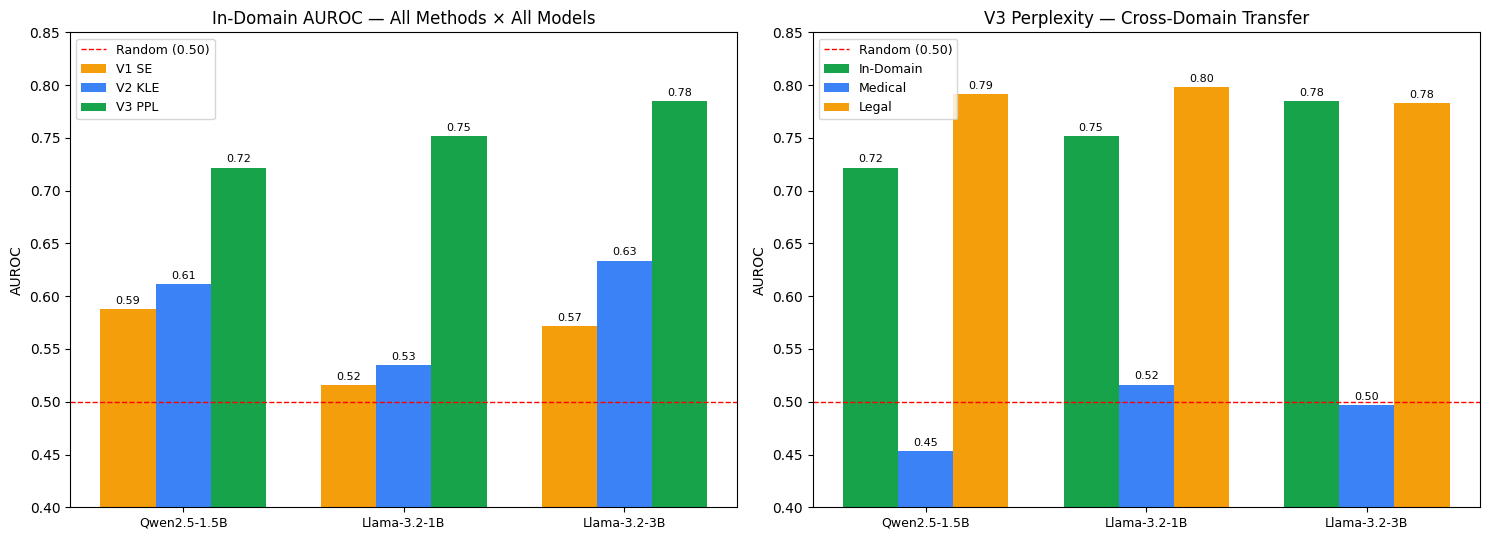

Final comparison chart saved to Drive!


In [4]:
import json, numpy as np
import matplotlib.pyplot as plt
save_dir = '/content/drive/MyDrive/DSA8_Task2'

with open(f'{save_dir}/task2_qwen_results.json')    as f: qwen   = json.load(f)
with open(f'{save_dir}/task2_llama1b_results.json') as f: llama1b = json.load(f)
with open(f'{save_dir}/task2_llama3b_results.json') as f: llama3b = json.load(f)
models = {'Qwen2.5-1.5B': qwen, 'Llama-3.2-1B': llama1b, 'Llama-3.2-3B': llama3b}
mnames = list(models.keys())

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

# ── CHART 1: Grouped bar — 3 methods × 3 models ──
x = np.arange(len(mnames)); w = 0.25
se  = [models[m]['V1_SemanticEntropy']['auroc']       for m in mnames]
kle = [models[m]['V2_KernelLanguageEntropy']['auroc'] for m in mnames]
ppl = [models[m]['V3_Perplexity_NLL']['auroc']        for m in mnames]

axes[0].bar(x-w, se,  w, label='V1 SE',  color='#F59E0B')
axes[0].bar(x,   kle, w, label='V2 KLE', color='#3B82F6')
axes[0].bar(x+w, ppl, w, label='V3 PPL', color='#16A34A')
axes[0].axhline(0.5, color='red', ls='--', lw=1, label='Random (0.50)')
axes[0].set_xticks(x); axes[0].set_xticklabels(mnames, fontsize=9)
axes[0].set_ylabel('AUROC'); axes[0].set_title('In-Domain AUROC — All Methods × All Models')
axes[0].legend(fontsize=9); axes[0].set_ylim(0.4, 0.85)
for i,(s,k,p) in enumerate(zip(se,kle,ppl)):
    axes[0].text(i-w, s+0.005, f'{s:.2f}', ha='center', fontsize=8)
    axes[0].text(i,   k+0.005, f'{k:.2f}', ha='center', fontsize=8)
    axes[0].text(i+w, p+0.005, f'{p:.2f}', ha='center', fontsize=8)

# ── CHART 2: V3 cross-domain ──
indomain = [models[m]['V3_Perplexity_NLL']['auroc']          for m in mnames]
medical  = [models[m]['cross_domain']['medical']['V3_PPL_auroc'] for m in mnames]
legal    = [models[m]['cross_domain']['legal']['V3_PPL_auroc']   for m in mnames]

axes[1].bar(x-w, indomain, w, label='In-Domain', color='#16A34A')
axes[1].bar(x,   medical,  w, label='Medical',   color='#3B82F6')
axes[1].bar(x+w, legal,    w, label='Legal',     color='#F59E0B')
axes[1].axhline(0.5, color='red', ls='--', lw=1, label='Random (0.50)')
axes[1].set_xticks(x); axes[1].set_xticklabels(mnames, fontsize=9)
axes[1].set_ylabel('AUROC'); axes[1].set_title('V3 Perplexity — Cross-Domain Transfer')
axes[1].legend(fontsize=9); axes[1].set_ylim(0.4, 0.85)
for i,(d,me,le) in enumerate(zip(indomain,medical,legal)):
    axes[1].text(i-w, d+0.005,  f'{d:.2f}', ha='center', fontsize=8)
    axes[1].text(i,   me+0.005, f'{me:.2f}', ha='center', fontsize=8)
    axes[1].text(i+w, le+0.005, f'{le:.2f}', ha='center', fontsize=8)

plt.tight_layout()
plt.savefig(f'{save_dir}/final_comparison_chart.png', dpi=120, bbox_inches='tight')
plt.show()
print('Final comparison chart saved to Drive!')